# Earthquake Damage Prediction (PRCP-1015)
### Predicting building damage grade after the 2015 Gorkha earthquake, Nepal

**Problem statement.** Each row in the dataset is one building in the region hit by the Gorkha earthquake. The task is to predict `damage_grade`, an ordinal variable:

| grade | meaning |
|---|---|
| 1 | low damage |
| 2 | medium damage |
| 3 | almost complete destruction |

**Tasks covered in this notebook**

1. A complete data analysis report on the data (Section 4).
2. A predictive model for the ordinal target `damage_grade` (Sections 5 to 10).
3. Suggestions to seismologists for reducing significant building damage (Section 14).
4. A model comparison report with a recommended production model (Sections 9 and 13).
5. A report on the challenges faced and the techniques used (Section 15).

**Data.** Two files: `train_values.csv` (260,601 buildings, 39 columns: `building_id` plus 38 features) and `train_labels.csv` (`building_id`, `damage_grade`). Categorical values are obfuscated into random letters, so a letter like `r` in `foundation_type` has no meaning I can decode, and the same letter in two different columns is unrelated.

### How the notebook is organised

| Section | Content |
|---|---|
| 1-3 | Setup, loading and checking the data, train/test split |
| 4 | Exploratory data analysis (Task 1) |
| 5-7 | Evaluation framework, baselines, preprocessing, model families, ordinal approaches, decision rule |
| 8 | Hyperparameter tuning of the finalists |
| 9 | Production model choice (made before touching the test set) |
| 10 | One-time evaluation on the test set |
| 11-12 | Interpretation and practical use of the predictions |
| 13 | Model comparison report |
| 14 | Suggestions to seismologists (Task 3) |
| 15 | Report on challenges faced |
| 16-17 | Limitations and conclusion |

**A note on how this was built.** I developed the notebook stage by stage and let each output decide the next step, so a few cells are kept on purpose as evidence of problems I ran into (the slow logistic regression check in 5.5 and the CatBoost error in 5.9). The kernel also had to be restarted once during tuning, so the execution counters are not in strict order. The long tuning searches and the final results were saved to disk with `joblib` after that, so they don't have to be recomputed.

## 1. Setup

Libraries, one fixed random seed (`RANDOM_STATE = 42`) used for every split and model, and a version check. The boosting libraries matter later, so I wanted to confirm they were installed before starting.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

!pip install xgboost lightgbm

# fixing one seed for the whole project so my splits and models come out the same on every rerun
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

# the boosting libraries will matter later, so I'd rather find out now whether they're installed
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("sklearn :", sklearn.__version__)
for lib in ["xgboost", "lightgbm", "catboost"]:
    try:
        mod = __import__(lib)
        print(f"{lib:8}:", mod.__version__)
    except ImportError:
        print(f"{lib:8}: not installed")

pandas  : 3.0.2
numpy   : 2.5.3
sklearn : 1.9.1
xgboost : 3.4.1
lightgbm: 4.7.0
catboost: 1.2.10


Versions used: pandas 3.0.2, numpy 2.5.3, scikit-learn 1.9.1, XGBoost 3.4.1, LightGBM 4.7.0, CatBoost 1.2.10. pandas 3 reads text columns with the new `str` dtype, which is why the categorical columns show up as `str` in the summary table below.

## 2. Loading and checking the data

Features and labels come in two separate files, so before combining them I check that `building_id` is unique in both and that both files describe the same buildings. I merge on the id with a one-to-one check instead of placing the columns side by side, so a row mismatch can't slip through quietly.

**Running this notebook on another computer:** `DATA_DIR` below points to the folder on my machine. Set it to the folder that contains `train_values.csv` and `train_labels.csv` before running.

In [2]:
DATA_DIR = r"C:\Users\sahup\Downloads\PRCP-1015-EquakeDamagePred (1)\Data"   # folder that has train_values.csv and train_labels.csv

values = pd.read_csv(os.path.join(DATA_DIR, "train_values.csv"))
labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"))

print("values shape:", values.shape)
print("labels shape:", labels.shape)
print("label columns:", labels.columns.tolist())

# features and labels come in separate files, so I don't want to trust that the rows line up.
# checking whether building_id is unique on both sides and whether it's the same set of ids
print("\nbuilding_id unique in values:", values["building_id"].is_unique)
print("building_id unique in labels:", labels["building_id"].is_unique)
print("same id set in both files   :", set(values["building_id"]) == set(labels["building_id"]))
print("same row order in both files:", (values["building_id"].values == labels["building_id"].values).all()
      if len(values) == len(labels) else "lengths differ")

# merging on the id instead of just concatenating, so a row mismatch can't slip through quietly
df = values.merge(labels, on="building_id", how="inner", validate="one_to_one")
print("\nmerged shape:", df.shape)
print(f"memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df.head()

values shape: (260601, 39)
labels shape: (260601, 2)
label columns: ['building_id', 'damage_grade']

building_id unique in values: True
building_id unique in labels: True
same id set in both files   : True
same row order in both files: True

merged shape: (260601, 40)
memory usage: 163.0 MB


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3


**Observation.** Both files have 260,601 rows, `building_id` is unique in each, and the two files contain the same ids in the same order. After the merge the data is 260,601 rows × 40 columns (about 163 MB in memory).

### 2.1 Structure, missing values, duplicates and the target

One summary table per column (type, number of unique values, missing values, examples), a duplicate check, and the target distribution. `building_id` is unique by design, so it is left out of the duplicate check, otherwise it would hide buildings that are identical in every recorded attribute.

In [3]:
# one summary table per column is easier for me to scan than reading df.info() and nunique() separately
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(3),
    "example_values": [df[c].dropna().unique()[:5].tolist() for c in df.columns],
})
print(summary.to_string())

# building_id is unique by design, so it would hide duplicate buildings. checking again with it left out
feat_cols = [c for c in df.columns if c not in ["building_id", "damage_grade"]]
print("\nexact duplicate rows (ignoring building_id):", df.duplicated(subset=feat_cols + ["damage_grade"]).sum())
print("same features but different label        :",
      df[df.duplicated(subset=feat_cols, keep=False)].groupby(feat_cols)["damage_grade"].nunique().gt(1).sum())

# the target first, since its balance decides how I split the data and which metrics make sense
print("\ndamage_grade counts:")
print(df["damage_grade"].value_counts().sort_index())
print("\ndamage_grade proportions:")
print(df["damage_grade"].value_counts(normalize=True).sort_index().round(4))

                                        dtype  n_unique  n_missing  pct_missing                          example_values
building_id                             int64    260601          0          0.0  [802906, 28830, 94947, 590882, 201944]
geo_level_1_id                          int64        31          0          0.0                      [6, 8, 21, 22, 11]
geo_level_2_id                          int64      1414          0          0.0               [487, 900, 363, 418, 131]
geo_level_3_id                          int64     11595          0          0.0        [12198, 2812, 8973, 10694, 1488]
count_floors_pre_eq                     int64         9          0          0.0                         [2, 3, 1, 4, 5]
age                                     int64        42          0          0.0                     [30, 10, 25, 0, 15]
area_percentage                         int64        84          0          0.0                         [6, 8, 5, 9, 3]
height_percentage                       

**Observations**

- **No missing values** in any column, so no imputation is needed. (The `age` column does hide a special code value, which comes up in 4.1.)
- The 38 features are: 3 geographic ids, 5 numeric columns, 8 obfuscated categorical columns and 22 binary flags.
- The geo levels have **31 / 1,414 / 11,595** distinct ids. These are labels for areas, not quantities, so their numeric order means nothing. How to represent them is one of the main decisions of the project.
- **12,319 rows** are exact copies of another row once `building_id` is ignored, and **3,825 feature profiles** occur with more than one damage grade. I kept all of them, because they are different buildings that happen to share recorded attributes. The conflicting labels do mean that the features cannot fully separate the grades, so some error is unavoidable for any model.
- **Target:** grade 1 = 25,124 (9.6%), grade 2 = 148,259 (56.9%), grade 3 = 87,218 (33.5%). Grade 1 is a small minority, so the split has to be stratified and accuracy on its own would not show how grade 1 is handled.

## 3. Train/test split

I set aside 20% of the buildings as a test set **before** looking at how any feature relates to the target. Several later choices (encoding the geography, the decision rule, tuning) depend on target patterns, and I didn't want test rows to influence any of them. The split is stratified on `damage_grade`.

All EDA from here on uses the training part only (`eda`). The test set is used once, in Section 10.

In [4]:
from sklearn.model_selection import train_test_split

# splitting before looking at feature-vs-target patterns, so the test rows never influence my decisions.
# stratifying because grade 1 is under 10% and I want the same balance in both parts
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["damage_grade"], random_state=RANDOM_STATE
)

print("train:", train_df.shape, " test:", test_df.shape)
print(pd.concat({
    "train": train_df["damage_grade"].value_counts(normalize=True).sort_index(),
    "test":  test_df["damage_grade"].value_counts(normalize=True).sort_index(),
}, axis=1).round(4))

# all EDA from here on runs on the training part only
eda = train_df.copy()

train: (208480, 40)  test: (52121, 40)
               train    test
damage_grade                
1             0.0964  0.0964
2             0.5689  0.5689
3             0.3347  0.3347


Train: 208,480 buildings, test: 52,121 buildings, with identical grade proportions (9.64% / 56.89% / 33.47%).

## 4. Exploratory data analysis (Task 1)

The EDA follows the questions the data raised: what the numeric columns look like and whether they contain odd values, whether the columns are internally consistent, how each group of features relates to damage, how strongly damage depends on location, and whether construction and location are tangled together. Every number in this section comes from the training part only.

### 4.1 Numeric columns

Summary statistics with extreme percentiles, the actual values of `age` (only 42 distinct values looked suspicious), histograms on a log scale so long tails stay visible, and box plots by damage grade.

                        count   mean    std  min   1%   25%   50%   75%   95%    99%    max
count_floors_pre_eq  208480.0   2.13   0.73  1.0  1.0   2.0   2.0   2.0   3.0    4.0    9.0
age                  208480.0  26.54  73.51  0.0  0.0  10.0  15.0  30.0  60.0  100.0  995.0
area_percentage      208480.0   8.02   4.40  1.0  2.0   5.0   7.0   9.0  16.0   24.0  100.0
height_percentage    208480.0   5.43   1.91  2.0  2.0   4.0   5.0   6.0   9.0   11.0   32.0
count_families       208480.0   0.98   0.42  0.0  0.0   1.0   1.0   1.0   2.0    2.0    9.0

unique age values: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(95), np.int64(100), np.int64(105), np.int64(110), np.int64(115), np.int64(120), np.int64(125), np.int64(130), np.int64(135), np.int64(140), np.int64(145),

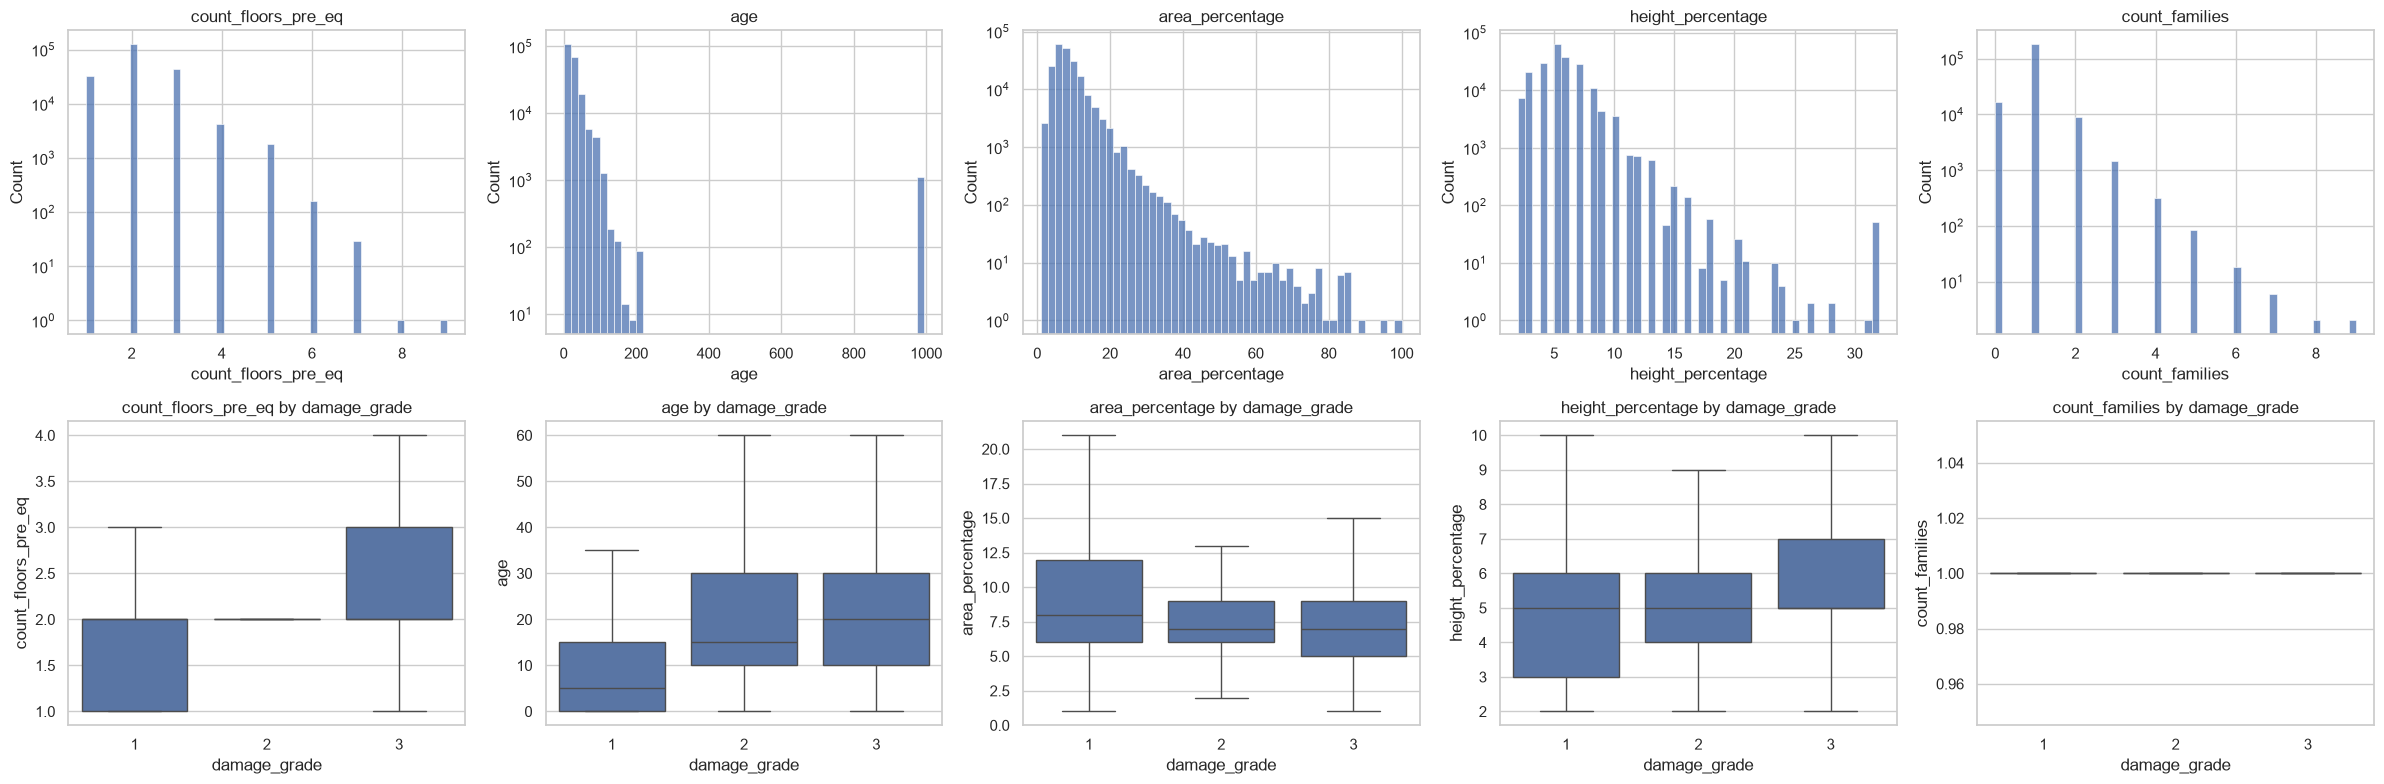

In [5]:
num_cols = ["count_floors_pre_eq", "age", "area_percentage", "height_percentage", "count_families"]

print(eda[num_cols].describe(percentiles=[.01, .25, .5, .75, .95, .99]).T.round(2))

# only 42 distinct ages looked suspicious to me, so I want to see the actual values and the top end
print("\nunique age values:", sorted(eda["age"].unique()))
print("\nlargest ages and their counts:")
print(eda["age"].value_counts().sort_index().tail(8))

# top row: overall shape (log y so the long tails stay visible)
# bottom row: how each column spreads within each damage grade (outlier dots hidden since there are ~208k points)
fig, axes = plt.subplots(2, len(num_cols), figsize=(24, 8))
for i, col in enumerate(num_cols):
    sns.histplot(eda[col], bins=50, ax=axes[0, i])
    axes[0, i].set_yscale("log")
    axes[0, i].set_title(col)
    sns.boxplot(data=eda, x="damage_grade", y=col, ax=axes[1, i], showfliers=False)
    axes[1, i].set_title(f"{col} by damage_grade")
plt.tight_layout()
plt.show()

**Observations**

- `count_floors_pre_eq`: almost all buildings have 1 to 3 floors (median 2, 99th percentile 4, max 9).
- `age` is recorded in steps of 5 years from 0 to 200, then jumps straight to **995**, which appears 1,110 times in the training data. 995 is clearly a code rather than a real age; I look at it in 4.3.
- `area_percentage` and `height_percentage` are right-skewed (area: median 7, max 100; height: median 5, max 32).
- `count_families` is almost always 1, so its box plot by grade is flat and uninformative. Discrete columns like this are better read as proportions, which 4.3 does.
- From the box plots: grade-1 buildings are clearly younger and have larger footprints, while grade-3 buildings tend to be taller with more floors.

### 4.2 Consistency checks

Checks that matter for later decisions: do the geo ids stay inside the documented ranges, are the three geo levels properly nested, how many superstructure materials does each building have, is `has_secondary_use` consistent with the specific use flags, how rare are the rarest flags, and how strongly do floors and height overlap.

In [6]:
# the doc gives value ranges for the geo levels, so I'm checking whether the full data stays inside them
for col, upper in [("geo_level_1_id", 30), ("geo_level_2_id", 1427), ("geo_level_3_id", 12567)]:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, documented max={upper}")

# if the levels are truly nested, every level-2 id belongs to exactly one level-1 id (same for 3 -> 2).
# this affects whether I can fall back from a rare level-3 area to its parent level during encoding
print("\nlevel-2 ids mapping to >1 level-1:", (df.groupby("geo_level_2_id")["geo_level_1_id"].nunique() > 1).sum())
print("level-3 ids mapping to >1 level-2:", (df.groupby("geo_level_3_id")["geo_level_2_id"].nunique() > 1).sum())

# one building can have several superstructure materials, so I'm counting how many each one has
super_cols = [c for c in eda.columns if c.startswith("has_superstructure")]
sec_cols = [c for c in eda.columns if c.startswith("has_secondary_use_")]
print("\nnumber of superstructure materials per building:")
print(eda[super_cols].sum(axis=1).value_counts().sort_index())

# has_secondary_use should be 1 exactly when at least one specific use flag is 1, so I'm checking that
print("\nhas_secondary_use vs any specific secondary-use flag:")
print(pd.crosstab(eda["has_secondary_use"], eda[sec_cols].max(axis=1),
                  rownames=["has_secondary_use"], colnames=["any_specific_flag"]))

# some flags are probably almost always 0, and those will carry very little signal
print("\nshare of buildings with each flag = 1:")
print(eda[super_cols + ["has_secondary_use"] + sec_cols].mean().sort_values().round(5).to_string())

# floors and height should describe roughly the same thing, and I want to see how strongly they overlap
print("\nSpearman corr floors vs height:",
      round(eda["count_floors_pre_eq"].corr(eda["height_percentage"], method="spearman"), 3))

geo_level_1_id: min=0, max=30, documented max=30
geo_level_2_id: min=0, max=1427, documented max=1427
geo_level_3_id: min=0, max=12567, documented max=12567

level-2 ids mapping to >1 level-1: 0
level-3 ids mapping to >1 level-2: 0

number of superstructure materials per building:
1    140839
2     46226
3     16162
4      3956
5      1014
6       253
7        26
8         4
Name: count, dtype: int64

has_secondary_use vs any specific secondary-use flag:
any_specific_flag       0      1
has_secondary_use               
0                  185201      0
1                       0  23279

share of buildings with each flag = 1:
has_secondary_use_use_police              0.00009
has_secondary_use_gov_office              0.00014
has_secondary_use_health_post             0.00017
has_secondary_use_school                  0.00038
has_secondary_use_institution             0.00095
has_secondary_use_industry                0.00108
has_secondary_use_other                   0.00513
has_secondary_use_r

**Observations**

- The geo id ranges match the documentation exactly (0-30, 0-1427, 0-12567).
- The hierarchy is **strictly nested**: no level-2 id belongs to more than one level-1 id, and no level-3 id to more than one level-2 id. So every small area has exactly one parent area.
- Every building has at least one superstructure material; 140,839 have exactly one and a few have up to 8. Mud-mortar stone is by far the most common (76.2% of buildings).
- `has_secondary_use` equals 1 exactly when at least one specific use flag is 1, with no mismatches. It is consistent but redundant.
- Some flags are extremely rare: police station 0.009% (19 buildings), government office 0.014%, health post 0.017%. Any damage pattern for these would be noise.
- Floors and height have a Spearman correlation of 0.755. They are related but not duplicates, so I kept both.

### 4.3 The `age = 995` code, and numeric features against damage

First I compare the 995 buildings with real age groups, both in damage and in construction, to see whether they behave like very old buildings or like something else. Then each numeric column is binned and shown as the share of each grade per bin, which works better than box plots for discrete columns.

            grade_1  grade_2  grade_3       n  mean_grade
age_group                                                
995 (code)    0.127    0.586    0.286    1110       2.159
0             0.278    0.488    0.235   20907       1.957
5-20          0.105    0.574    0.322  112534       2.217
25-50         0.036    0.579    0.384   60490       2.348
55-100        0.015    0.604    0.380   12853       2.365
105-200       0.014    0.621    0.365     586       2.352

construction profile, age=995 vs the rest:
         count_floors_pre_eq  has_superstructure_mud_mortar_stone  has_superstructure_adobe_mud  has_superstructure_rc_engineered  has_superstructure_cement_mortar_brick  has_superstructure_timber
age                                                                                                                                                                                                 
other                  2.129                                0.763                         0.088   

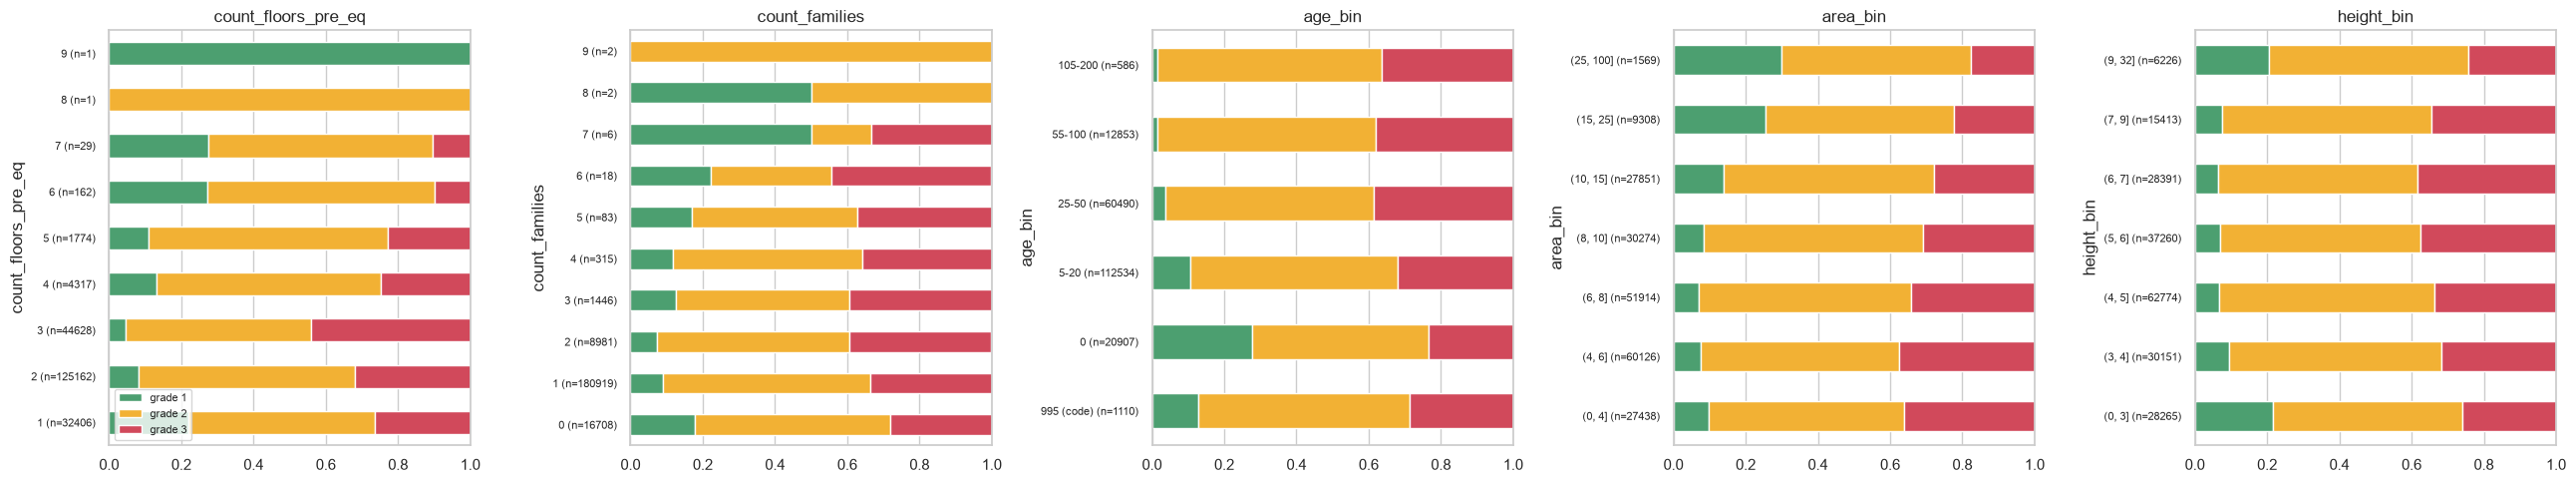

In [7]:
# helper I'll reuse: share of each grade within each level of a column, plus count and mean grade
def grade_share(data, col):
    ct = pd.crosstab(data[col], data["damage_grade"])
    out = ct.div(ct.sum(axis=1), axis=0).round(3)
    out.columns = [f"grade_{c}" for c in out.columns]
    out["n"] = ct.sum(axis=1)
    out["mean_grade"] = data.groupby(col, observed=True)["damage_grade"].mean().round(3)
    return out

def plot_grade_share(data, col, ax):
    tab = grade_share(data, col)
    tab[["grade_1", "grade_2", "grade_3"]].plot(kind="barh", stacked=True, ax=ax,
                                                color=["#4c9f70", "#f2b134", "#d1495b"], legend=False)
    ax.set_yticklabels([f"{idx} (n={n})" for idx, n in zip(tab.index, tab["n"])], fontsize=8)
    ax.set_title(col)
    ax.set_xlim(0, 1)

# the 995 buildings next to the oldest "real" ages, to see whether they behave like old buildings or like something else
age_view = eda.assign(age_group=pd.cut(eda["age"].replace(995, -1),
                                       bins=[-2, -0.5, 0, 20, 50, 100, 200],
                                       labels=["995 (code)", "0", "5-20", "25-50", "55-100", "105-200"]))
print(grade_share(age_view, "age_group"))

# checking if 995 buildings also differ in construction, which would hint at what the code means
compare_cols = ["count_floors_pre_eq", "has_superstructure_mud_mortar_stone", "has_superstructure_adobe_mud",
                "has_superstructure_rc_engineered", "has_superstructure_cement_mortar_brick", "has_superstructure_timber"]
print("\nconstruction profile, age=995 vs the rest:")
print(eda.groupby(eda["age"] == 995)[compare_cols].mean().round(3).rename(index={True: "age=995", False: "other"}))

# binning the continuous-ish columns so every level has enough buildings to read a share from
binned = eda.assign(
    age_bin=age_view["age_group"],
    area_bin=pd.cut(eda["area_percentage"], bins=[0, 4, 6, 8, 10, 15, 25, 100]),
    height_bin=pd.cut(eda["height_percentage"], bins=[0, 3, 4, 5, 6, 7, 9, 32]),
)
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for ax, col in zip(axes, ["count_floors_pre_eq", "count_families", "age_bin", "area_bin", "height_bin"]):
    plot_grade_share(binned, col, ax)
axes[0].legend(["grade 1", "grade 2", "grade 3"], loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

**Observations**

- The 995 buildings have a mean grade of 2.159. That is closer to the 5-20 year group (2.217) than to buildings older than 25 years (about 2.35), and their construction profile is only slightly different (adobe 13.7% vs 8.8%, timber 34.9% vs 25.4%). So I read 995 as **"age unknown"**, not as "995 years old". In preprocessing it gets its own `age_unknown` flag and the value itself is replaced by the median of the training fold.
- New buildings stand out: 27.8% of age-0 buildings are grade 1, against 10.5% for 5-20 years. The mean grade then rises to about 2.35 at 25-50 years and stays roughly flat after that.
- Floors: the grade-3 share is highest at 3 floors and lower again for 4 or more floors, so the relationship is not monotonic.
- Area: larger footprints go with more grade 1 (about 30% in the largest area bin).
- Height: both the lowest and the highest bins have more grade 1 than the middle bins, again non-monotonic.
- These non-monotonic patterns are one reason to expect tree-based models to do better than a linear model.

### 4.4 Categorical columns

Grade shares, counts and mean grade for each level of the eight categorical columns. Tables are printed next to the plots because small categories are easy to miss in a bar chart.


--- land_surface_condition ---
                        grade_1  grade_2  grade_3       n  mean_grade
land_surface_condition                                               
t                         0.101    0.563    0.335  173484       2.234
n                         0.072    0.604    0.324   28330       2.252
o                         0.074    0.564    0.362    6666       2.288

--- foundation_type ---
                 grade_1  grade_2  grade_3       n  mean_grade
foundation_type                                               
r                  0.049    0.572    0.379  175413       2.329
w                  0.288    0.613    0.099   12034       1.811
u                  0.256    0.603    0.141   11411       1.884
i                  0.567    0.412    0.021    8473       1.454
h                  0.259    0.390    0.351    1149       2.091

--- roof_type ---
           grade_1  grade_2  grade_3       n  mean_grade
roof_type                                               
n            0.075 

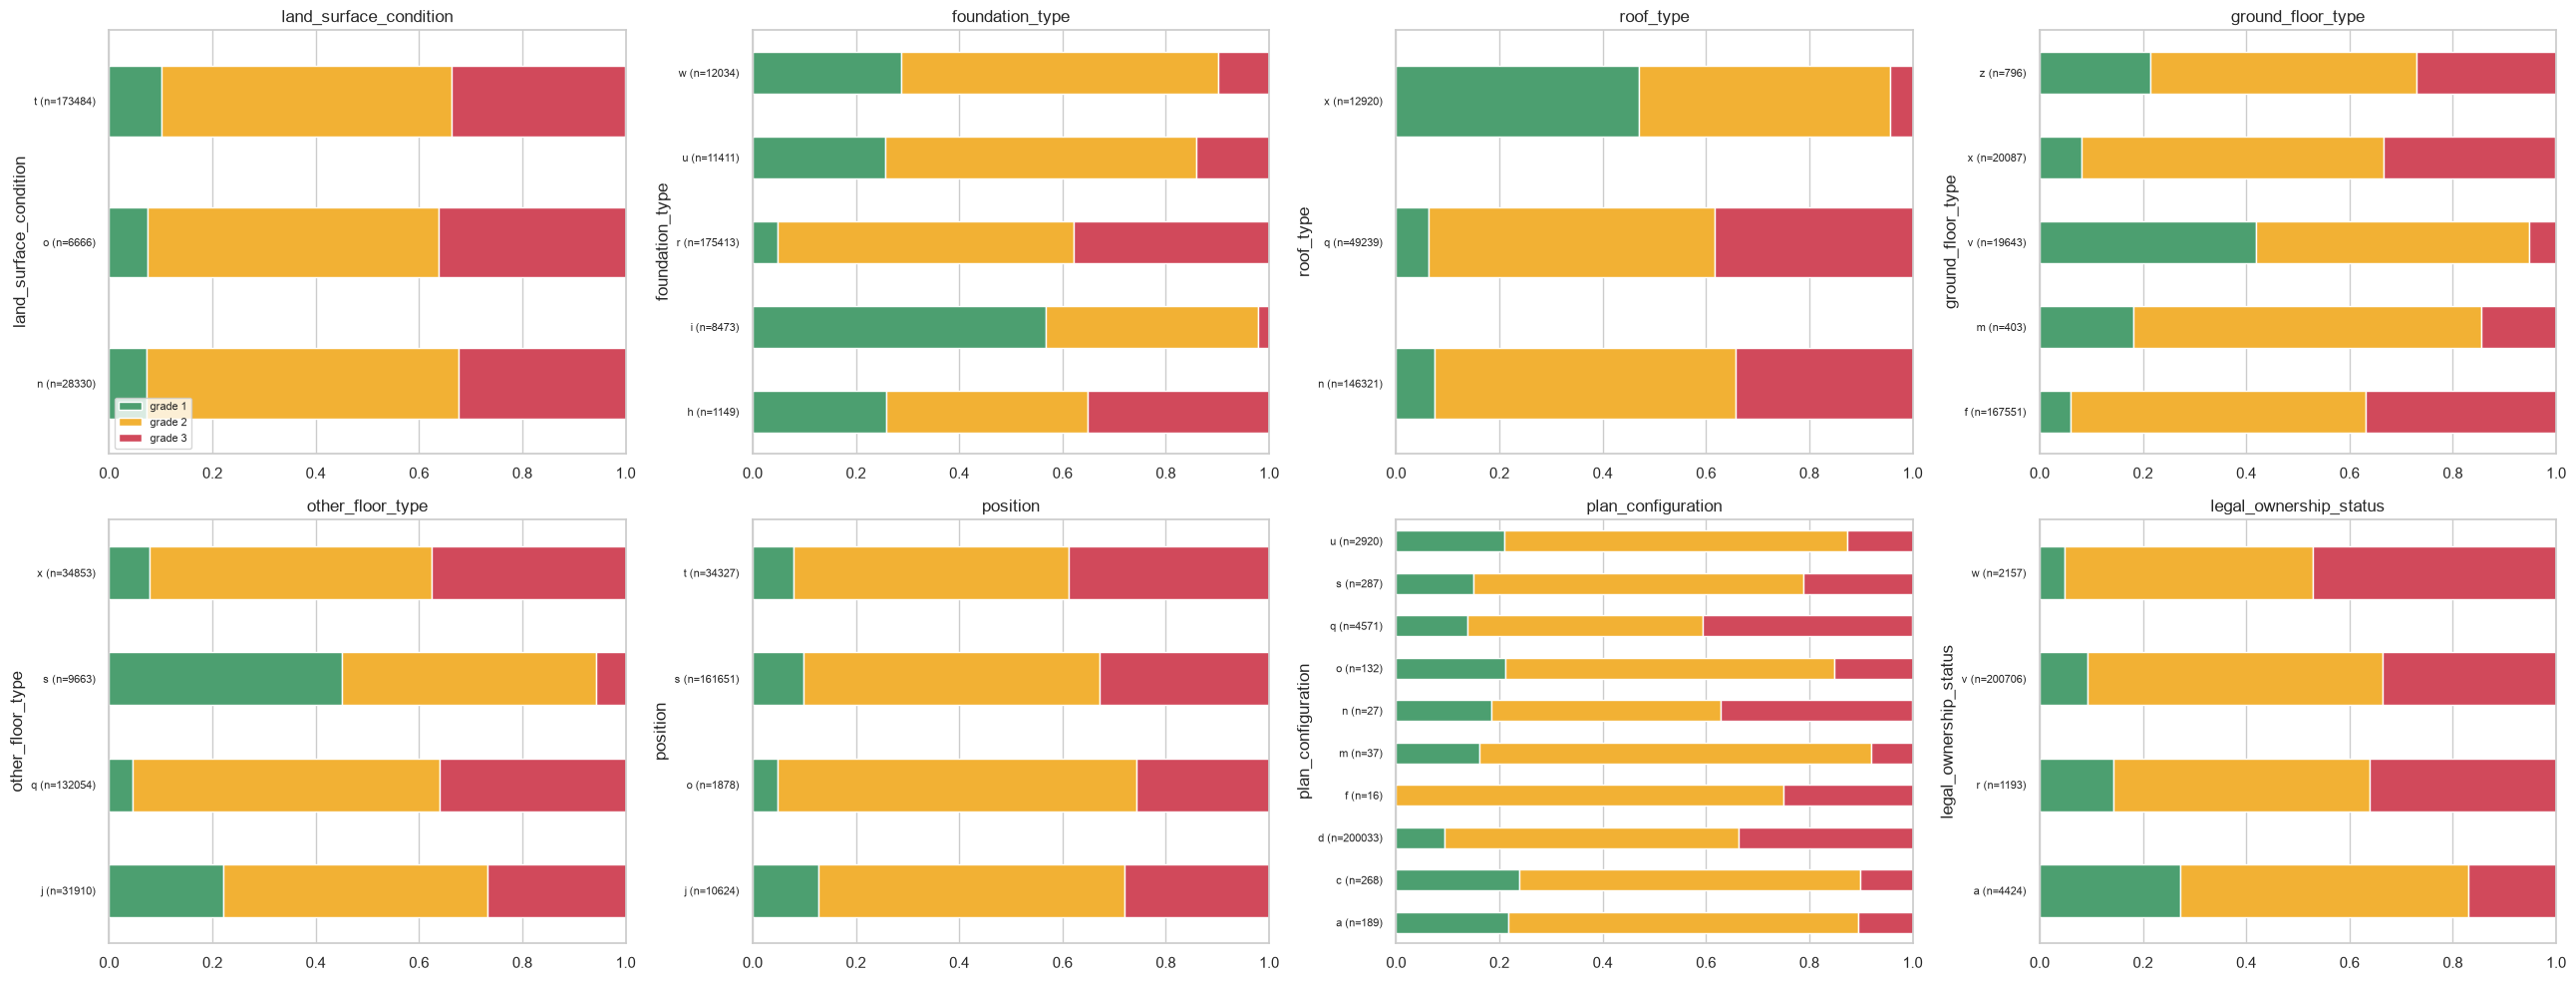

In [8]:
cat_cols = ["land_surface_condition", "foundation_type", "roof_type", "ground_floor_type",
            "other_floor_type", "position", "plan_configuration", "legal_ownership_status"]

# printing tables as well as plots, because small categories are easy to miss in a bar chart
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(grade_share(eda, col).sort_values("n", ascending=False))

fig, axes = plt.subplots(2, 4, figsize=(26, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    plot_grade_share(eda, col, ax)
axes[0, 0].legend(["grade 1", "grade 2", "grade 3"], loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

**Observations**

- `foundation_type` shows the strongest contrast: level `i` has 56.7% grade 1 and only 2.1% grade 3 (8,473 buildings), while level `r`, which covers most buildings (175,413), has 4.9% grade 1 and 37.9% grade 3.
- Similar low-damage levels exist in other columns: `roof_type = x` (47.1% grade 1), `ground_floor_type = v` (41.9%) and `other_floor_type = s` (45.0%). I suspected these describe the same kind of building, which 4.8 checks.
- `land_surface_condition` and `position` are weak: mean grades only range from about 2.15 to 2.31.
- `plan_configuration` is 96% level `d`, and some levels are tiny (`f` = 16, `n` = 27, `m` = 37 buildings). Rare levels need grouping when one-hot encoding.
- `legal_ownership_status = w` has the highest grade-3 share of any category (47.1%), but only 2,157 buildings.

The letters are obfuscated, so I can describe these levels only by their codes, not by what they physically are.

### 4.5 Binary flags

For every flag: the mean grade when the flag is 1 versus 0, and the grade-1 and grade-3 shares. Flags present in fewer than 500 buildings are marked (grey in the plot) because their differences are not reliable.

overall mean grade in train: 2.238

                                        n_with_flag  mean_grade_flag1  mean_grade_flag0  grade1_share_flag1  grade3_share_flag1   diff  low_support
flag                                                                                                                                               
has_superstructure_rc_engineered               3322             1.377             2.252               0.641               0.019 -0.875        False
has_superstructure_cement_mortar_brick        15661             1.697             2.282               0.359               0.056 -0.585        False
has_secondary_use_institution                   198             1.662             2.239               0.409               0.071 -0.577         True
has_secondary_use_rental                       1684             1.669             2.243               0.417               0.086 -0.574        False
has_secondary_use_gov_office                     30             1.733       

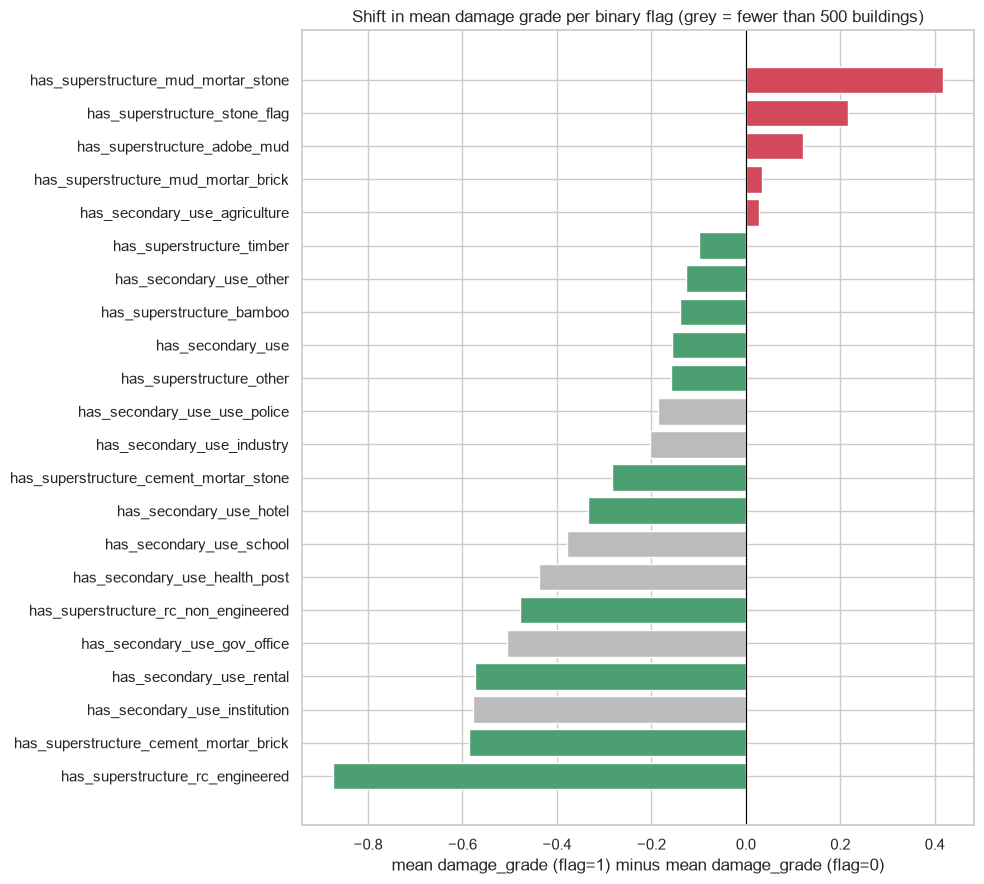

In [9]:
flag_cols = super_cols + ["has_secondary_use"] + sec_cols
overall_mean = eda["damage_grade"].mean()

rows = []
for col in flag_cols:
    on = eda.loc[eda[col] == 1, "damage_grade"]
    off = eda.loc[eda[col] == 0, "damage_grade"]
    rows.append({
        "flag": col,
        "n_with_flag": len(on),
        "mean_grade_flag1": on.mean(),
        "mean_grade_flag0": off.mean(),
        "grade1_share_flag1": (on == 1).mean(),
        "grade3_share_flag1": (on == 3).mean(),
    })
flag_tab = pd.DataFrame(rows).set_index("flag")
flag_tab["diff"] = flag_tab["mean_grade_flag1"] - flag_tab["mean_grade_flag0"]
# below ~500 buildings I don't trust the difference much, so I'm marking those rather than reading into them
flag_tab["low_support"] = flag_tab["n_with_flag"] < 500
print(f"overall mean grade in train: {overall_mean:.3f}\n")
print(flag_tab.sort_values("diff").round(3).to_string())

plot_tab = flag_tab.sort_values("diff")
colors = ["#bbbbbb" if low else ("#4c9f70" if d < 0 else "#d1495b")
          for d, low in zip(plot_tab["diff"], plot_tab["low_support"])]
plt.figure(figsize=(10, 9))
plt.barh(plot_tab.index, plot_tab["diff"], color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("mean damage_grade (flag=1) minus mean damage_grade (flag=0)")
plt.title("Shift in mean damage grade per binary flag (grey = fewer than 500 buildings)")
plt.tight_layout()
plt.show()

**Observations** (overall mean grade in train = 2.238)

- **Lowest damage:** engineered reinforced concrete (mean grade 1.377 vs 2.252 without it, a difference of −0.875, with 64.1% grade 1), then cement-mortar brick (−0.585) and non-engineered RC (−0.479).
- **Highest damage:** mud-mortar stone (+0.418, 158,958 buildings), stone (+0.216) and adobe/mud (+0.121).
- Rental use (−0.574) and hotel use (−0.333) also go with lower damage. I wouldn't read that as "renting protects a building"; these buildings are more likely to be modern or in different areas, which is a confounding story. 4.9 checks this kind of effect within the same region.
- The grey flags (police, school, health post and so on) are based on 19 to 226 buildings, so I don't interpret them.

### 4.6 Damage by location

The 31 top-level regions are few enough to look at one by one, sorted from least to most damaged. For the level-2 areas I plot the distribution of mean grade, keeping only areas with at least 30 buildings so the spread isn't just small-sample noise.

                grade_1  grade_2  grade_3      n  mean_grade
geo_level_1_id                                              
26                0.353    0.559    0.088  18026       1.734
24                0.203    0.700    0.097   1049       1.894
5                 0.169    0.743    0.088   2148       1.919
20                0.193    0.687    0.120  13701       1.927
13                0.207    0.647    0.146   7745       1.938
1                 0.154    0.737    0.109   2154       1.955
22                0.132    0.735    0.133   5009       2.001
9                 0.144    0.692    0.164   3203       2.020
30                0.093    0.792    0.114   2172       2.021
19                0.130    0.695    0.175    285       2.046
25                0.086    0.779    0.135   4519       2.049
14                0.110    0.725    0.165   1383       2.055
0                 0.083    0.763    0.153   3210       2.070
29                0.019    0.885    0.096    322       2.078
15                0.071 

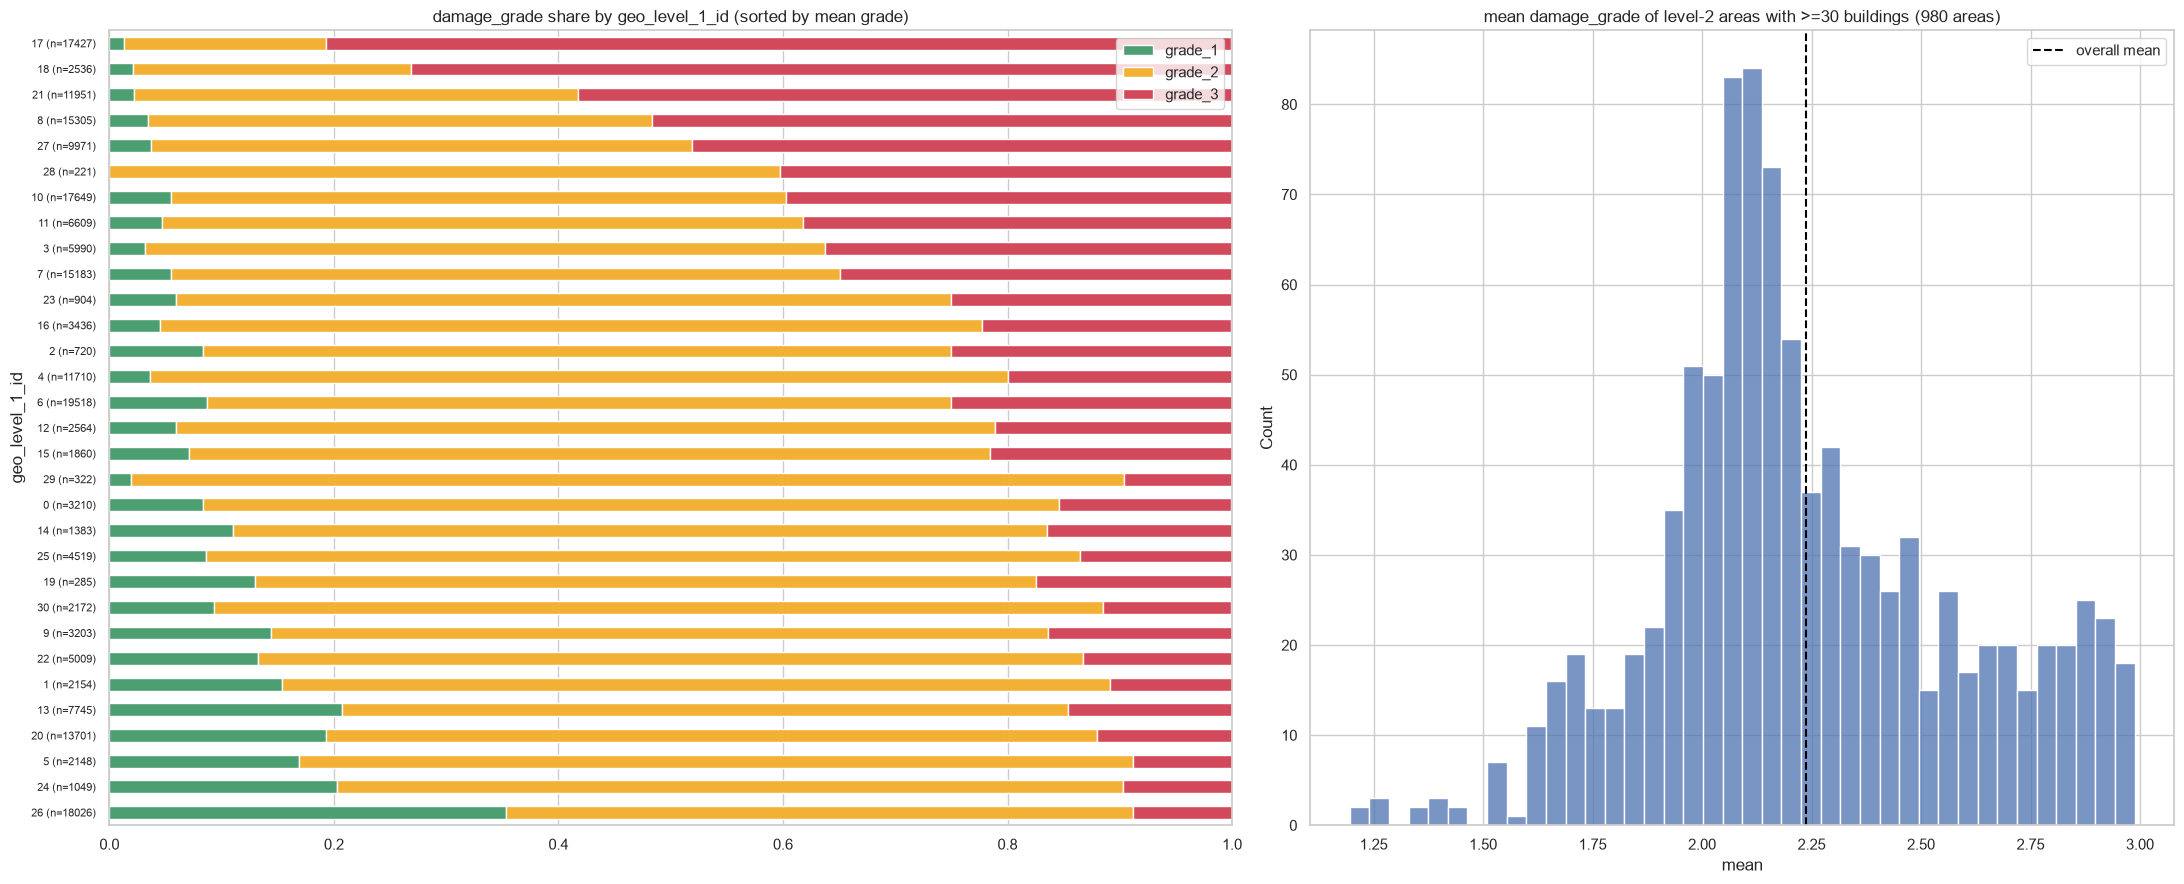

In [10]:
# 31 top-level regions is still small enough to look at one by one, sorted from least to most damaged
tab1 = grade_share(eda, "geo_level_1_id").sort_values("mean_grade")
print(tab1.to_string())

fig, axes = plt.subplots(1, 2, figsize=(22, 9), gridspec_kw={"width_ratios": [1.3, 1]})
tab1[["grade_1", "grade_2", "grade_3"]].plot(kind="barh", stacked=True, ax=axes[0],
                                             color=["#4c9f70", "#f2b134", "#d1495b"])
axes[0].set_yticklabels([f"{i} (n={n})" for i, n in zip(tab1.index, tab1["n"])], fontsize=8)
axes[0].set_title("damage_grade share by geo_level_1_id (sorted by mean grade)")
axes[0].set_xlim(0, 1)

# for level 2, I'm only keeping areas with at least 30 buildings, so the spread isn't just small-sample noise
lvl2 = eda.groupby("geo_level_2_id")["damage_grade"].agg(["mean", "size"])
lvl2_big = lvl2[lvl2["size"] >= 30]
sns.histplot(lvl2_big["mean"], bins=40, ax=axes[1])
axes[1].axvline(eda["damage_grade"].mean(), color="black", ls="--", label="overall mean")
axes[1].set_title(f"mean damage_grade of level-2 areas with >=30 buildings ({len(lvl2_big)} areas)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Observations**

- The differences between regions are very large. Region 26 has a mean grade of 1.734 (35.3% grade 1, 8.8% grade 3), while region 17 has a mean grade of 2.793 with **80.6% grade 3**. Regions 18 (73.1%), 21 (58.3%) and 8 (51.8%) are also above 50% grade 3.
- The 980 level-2 areas with at least 30 buildings range from a mean grade of about 1.2 up to 3.0, with a long tail of heavily damaged areas above 2.5.
- A likely reason is how strongly the ground shook in each place (distance from the rupture, local soil), but the ids are obfuscated and the data has no shaking or soil variable, so this can't be confirmed. Regional building practices could also play a part. Within this dataset I can only say that **location is strongly associated with damage**.

### 4.7 How reliable are area-level estimates?

The obvious way to use the geo ids is each area's average damage. With thousands of small areas that can overfit, so for each geo level I check how many buildings each id has, how many test buildings fall in areas never seen in training (this uses test ids only, never test labels), and how much variance the area mean explains **in-sample** (each building's own label included) versus **out-of-fold** (area means computed from other folds only).

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score

geo_cols = ["geo_level_1_id", "geo_level_2_id", "geo_level_3_id"]
y_eda = eda["damage_grade"].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for col in geo_cols:
    counts = eda[col].value_counts()
    # "seen in train" only uses test ids, not test labels, to check how many areas a model would meet for the first time
    unseen_test = (~test_df[col].isin(counts.index)).mean()

    # in-sample: each building's own label is part of its area mean, so this is optimistic by design
    in_sample = eda[col].map(eda.groupby(col)["damage_grade"].mean()).values

    # out-of-fold: the area mean comes only from other folds, which is how it would behave on new buildings
    oof = np.full(len(eda), np.nan)
    for tr_idx, va_idx in skf.split(eda, y_eda):
        fold_means = eda.iloc[tr_idx].groupby(col)["damage_grade"].mean()
        oof[va_idx] = eda.iloc[va_idx][col].map(fold_means).values
    oof = np.where(np.isnan(oof), y_eda.mean(), oof)

    rows.append({
        "column": col,
        "ids_in_train": counts.size,
        "median_buildings_per_id": counts.median(),
        "ids_with_<5": (counts < 5).sum(),
        "ids_with_<30": (counts < 30).sum(),
        "buildings_in_ids_<30": counts[counts < 30].sum() / len(eda),
        "test_rows_unseen_id": unseen_test,
        "R2_in_sample": r2_score(y_eda, in_sample),
        "R2_out_of_fold": r2_score(y_eda, oof),
    })

geo_support = pd.DataFrame(rows).set_index("column")
print(geo_support.round(4).T.to_string())

column                   geo_level_1_id  geo_level_2_id  geo_level_3_id
ids_in_train                    31.0000       1409.0000      11380.0000
median_buildings_per_id       3436.0000         97.0000         12.0000
ids_with_<5                      0.0000         95.0000       3052.0000
ids_with_<30                     0.0000        429.0000       9303.0000
buildings_in_ids_<30             0.0000          0.0257          0.4663
test_rows_unseen_id              0.0000          0.0001          0.0049
R2_in_sample                     0.2189          0.3416          0.4292
R2_out_of_fold                   0.2187          0.3318          0.3597


**Observations**

| | level 1 | level 2 | level 3 |
|---|---|---|---|
| ids in train | 31 | 1,409 | 11,380 |
| median buildings per id | 3,436 | 97 | **12** |
| ids with fewer than 30 buildings | 0 | 429 | 9,303 |
| share of buildings in those ids | 0 | 2.6% | **46.6%** |
| test rows in unseen ids | 0 | 0.01% | 0.49% |
| R² in-sample | 0.219 | 0.342 | **0.429** |
| R² out-of-fold | 0.219 | 0.332 | **0.360** |

- Level 1 alone explains about 22% of the variance in damage grade.
- At level 3 the in-sample R² is about 0.07 higher than the out-of-fold R². That gap is the leak: a raw area mean partly contains the building's own label. At levels 1 and 2 the gap is close to zero.
- Level 3 is still the most informative level out-of-fold (0.360 vs 0.332), so it is worth keeping, but it **must be encoded with cross-fitting** (the area mean for a building computed without that building's label) and with smoothing for small areas.
- Only 0.49% of test buildings fall in a level-3 area unseen in training, so new areas are rare in this split.

### 4.8 Do the construction features overlap?

Cramér's V measures association between two categorical variables (0 = unrelated, 1 = one fully determines the other). I compute it between the construction-related features and `damage_grade` to see whether the low-damage categories from 4.4 and 4.5 describe the same buildings.

has_superstructure_mud_mortar_stone       0.334
foundation_type                           0.305
has_superstructure_cement_mortar_brick    0.277
ground_floor_type                         0.264
other_floor_type                          0.245
roof_type                                 0.240
has_superstructure_rc_engineered          0.237
has_superstructure_rc_non_engineered      0.186
legal_ownership_status                    0.070
plan_configuration                        0.057
position                                  0.045
land_surface_condition                    0.029
Name: damage_grade, dtype: float64


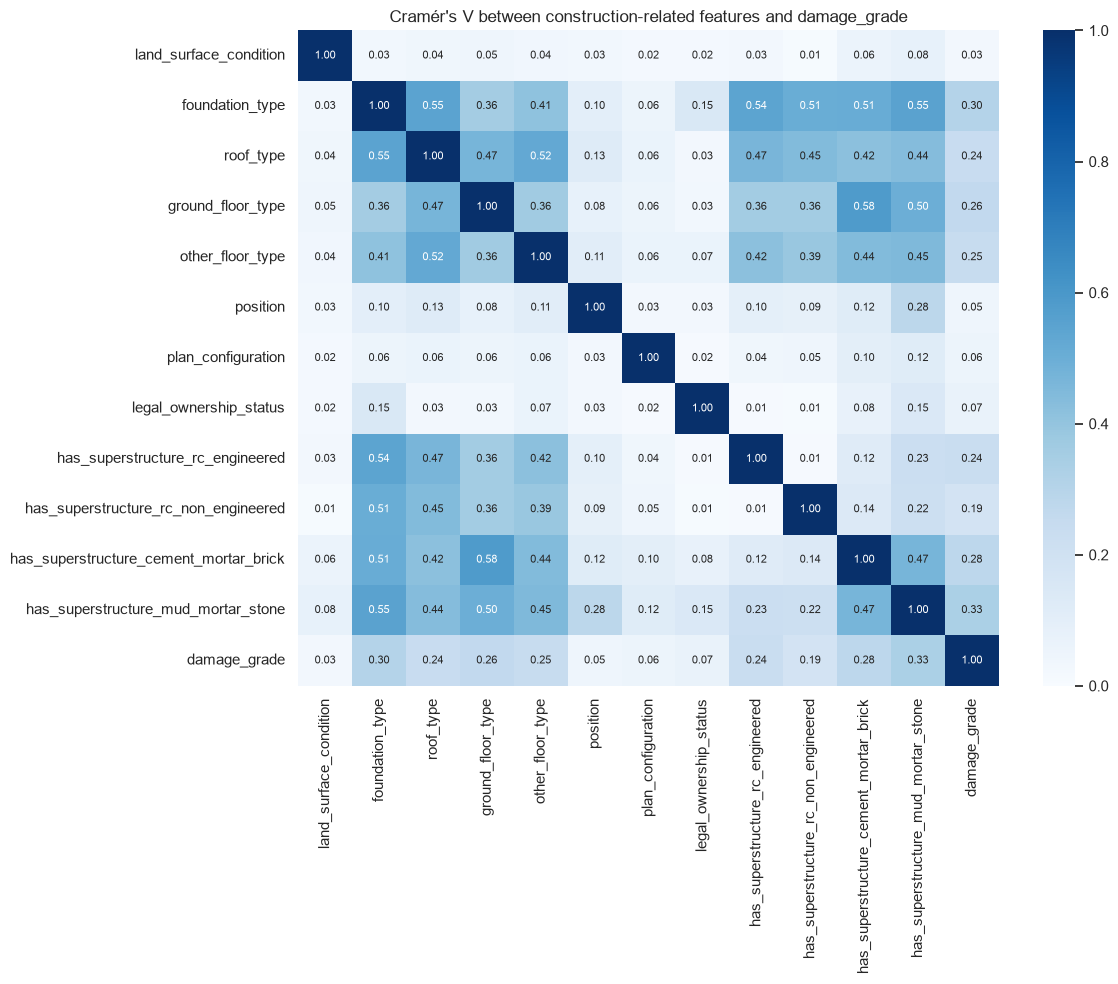

In [12]:
from scipy.stats import chi2_contingency

# Cramér's V works for any pair of categorical columns (0 = unrelated, 1 = one fully determines the other)
def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct, correction=False)[0]
    return np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

assoc_cols = cat_cols + ["has_superstructure_rc_engineered", "has_superstructure_rc_non_engineered",
                         "has_superstructure_cement_mortar_brick", "has_superstructure_mud_mortar_stone",
                         "damage_grade"]

cv = pd.DataFrame(np.eye(len(assoc_cols)), index=assoc_cols, columns=assoc_cols)
for i, a in enumerate(assoc_cols):
    for b in assoc_cols[i + 1:]:
        cv.loc[a, b] = cv.loc[b, a] = cramers_v(eda[a], eda[b])

print(cv["damage_grade"].drop("damage_grade").sort_values(ascending=False).round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(cv.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, annot_kws={"size": 8})
plt.title("Cramér's V between construction-related features and damage_grade")
plt.tight_layout()
plt.show()

**Observations**

- The strongest single associations with damage are mud-mortar stone (0.334), foundation type (0.305) and cement-mortar brick (0.277), followed by the floor and roof types (0.24-0.26) and engineered RC (0.237).
- Land surface, position, plan configuration and legal status are weak (0.03-0.07).
- Foundation, roof, the two floor types, RC, cement brick and mud-mortar stone are associated **with each other** at about 0.36-0.58. So they partly describe the same kind of building, but none of them is redundant (nothing near 0.8). I kept all of them. The overlap matters for interpretation, though: the same underlying effect can show up in several features at once, so I avoid counting it several times in the suggestions.

### 4.9 Do the construction associations survive within the same region?

Location and construction could be tangled together: if one region has mostly RC buildings and also experienced weak shaking, part of the "RC effect" would really be a location effect. So I compare buildings with and without each feature **inside each geo_level_1 region**, and average those within-region differences (weighted by the number of buildings with the feature). Regions where either side has fewer than 20 buildings are skipped.

                                        raw_diff  within_region_diff  regions_used  share_of_raw_kept
feature                                                                                              
has_superstructure_rc_engineered          -0.875              -0.807            16              0.923
foundation_type=i                         -0.817              -0.792            22              0.968
roof_type=x                               -0.709              -0.676            22              0.954
other_floor_type=s                        -0.662              -0.660            22              0.997
ground_floor_type=v                       -0.667              -0.553            25              0.830
has_secondary_use_rental                  -0.574              -0.527            15              0.917
has_superstructure_cement_mortar_brick    -0.585              -0.444            20              0.759
has_superstructure_rc_non_engineered      -0.479              -0.427            26

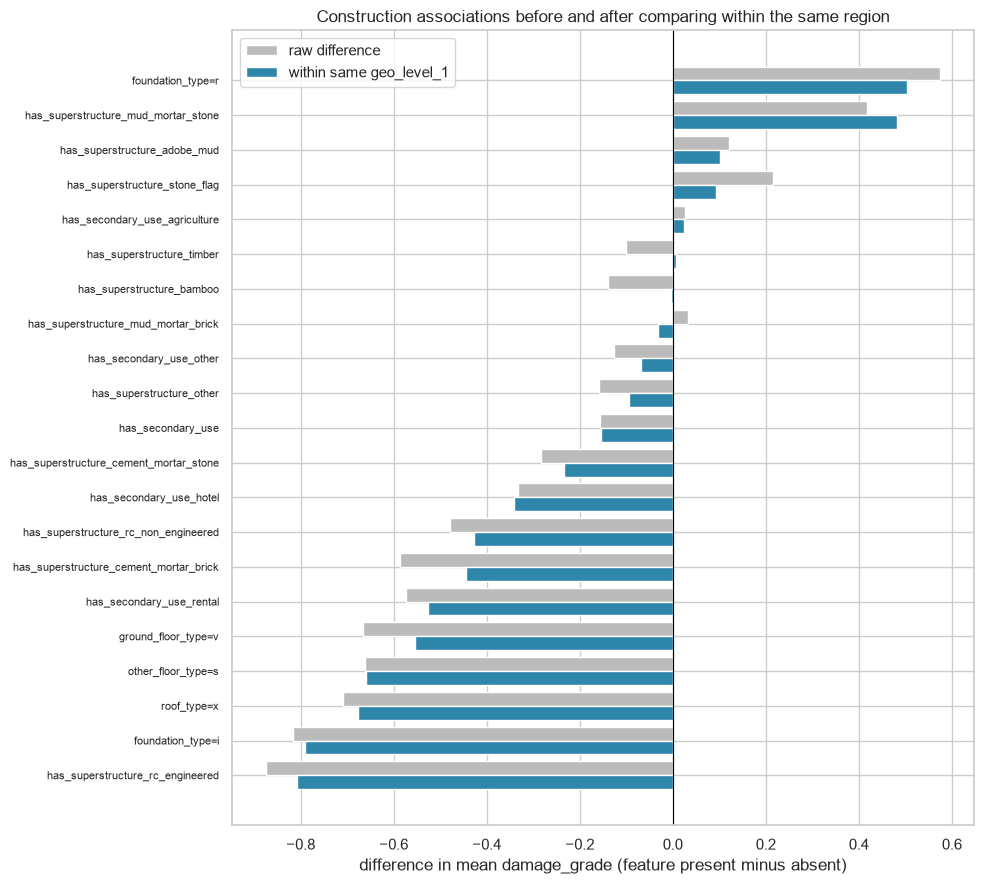

In [13]:
# raw differences mix construction with location, so here I compare flag=1 vs flag=0 inside each
# geo_level_1 region and then average those differences weighted by how many flagged buildings each region has
def within_region_diff(data, col):
    diffs, weights = [], []
    for _, g in data.groupby("geo_level_1_id"):
        on, off = g.loc[g[col] == 1, "damage_grade"], g.loc[g[col] == 0, "damage_grade"]
        if len(on) >= 20 and len(off) >= 20:          # skipping regions where one side is too small to compare
            diffs.append(on.mean() - off.mean())
            weights.append(len(on))
    return np.average(diffs, weights=weights) if diffs else np.nan, len(diffs)

check_flags = [c for c in flag_tab.index if not flag_tab.loc[c, "low_support"]]
# the strong categories from Cell 8, turned into 0/1 so they go through the same comparison
cat_checks = {"foundation_type=i": ("foundation_type", "i"), "foundation_type=r": ("foundation_type", "r"),
              "roof_type=x": ("roof_type", "x"), "ground_floor_type=v": ("ground_floor_type", "v"),
              "other_floor_type=s": ("other_floor_type", "s")}
tmp = eda.copy()
for name, (col, val) in cat_checks.items():
    tmp[name] = (tmp[col] == val).astype(int)

rows = []
for col in check_flags + list(cat_checks):
    raw = tmp.loc[tmp[col] == 1, "damage_grade"].mean() - tmp.loc[tmp[col] == 0, "damage_grade"].mean()
    within, n_regions = within_region_diff(tmp, col)
    rows.append({"feature": col, "raw_diff": raw, "within_region_diff": within, "regions_used": n_regions})

adj = pd.DataFrame(rows).set_index("feature")
adj["share_of_raw_kept"] = adj["within_region_diff"] / adj["raw_diff"]
print(adj.sort_values("within_region_diff").round(3).to_string())

plot_adj = adj.sort_values("within_region_diff")
y_pos = np.arange(len(plot_adj))
plt.figure(figsize=(10, 9))
plt.barh(y_pos + 0.2, plot_adj["raw_diff"], height=0.4, label="raw difference", color="#bbbbbb")
plt.barh(y_pos - 0.2, plot_adj["within_region_diff"], height=0.4, label="within same geo_level_1", color="#2e86ab")
plt.yticks(y_pos, plot_adj.index, fontsize=8)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("difference in mean damage_grade (feature present minus absent)")
plt.title("Construction associations before and after comparing within the same region")
plt.legend()
plt.tight_layout()
plt.show()

**Observations**

- Most construction associations hold within the same region. Engineered RC keeps 92% of its raw difference (−0.875 → −0.807), `foundation_type = i` keeps 97%, `roof_type = x` 95% and `other_floor_type = s` almost all of it.
- Mud-mortar stone actually gets **stronger** within regions (+0.418 → +0.481).
- **Timber and bamboo lose their effect completely** (−0.100 → +0.008 and −0.138 → −0.005). Their apparent "lower damage" came almost entirely from where those buildings are. Without this check I would have wrongly called them protective.
- Stone drops by more than half (+0.216 → +0.093), and cement-mortar brick keeps about 76%.
- This only controls for location at the coarsest level (31 regions), so it is a stronger comparison than the raw one but still observational, not causal.

### 4.10 EDA summary and what it means for modelling

| Finding | Consequence for the modelling |
|---|---|
| Target is ordinal and imbalanced (9.6 / 56.9 / 33.5%) | Stratified split and folds; metrics that respect the order of grades; grade-1 handling has to be checked explicitly |
| `age = 995` behaves like "unknown" | Separate `age_unknown` flag, value replaced by the training-fold median |
| Geo level 3: 11,595 ids, median 12 buildings, raw means overfit | Cross-fitted target encoding inside the pipeline, or a model that handles categories itself |
| Location is the strongest single factor | Geography has to be represented carefully; interpretations must not confuse location with construction |
| Non-monotonic effects (floors, height) and interacting features | Tree-based models are expected to beat a linear model |
| Construction features overlap (Cramér's V 0.36-0.58) | Keep all, but interpret them as a group |
| Rare categories and rare flags | Rare-level grouping for one-hot encoding; rare flags not interpreted |
| 3,825 conflicting duplicate profiles | A ceiling on achievable accuracy; no model will separate these buildings |

## 5. Evaluation framework, baselines and first models (Task 2)

### 5.1 Evaluation framework

All models are compared under one protocol:

- **The same 5 stratified folds** on the training set, fixed once, so every model is scored on exactly the same splits. The test set stays untouched.
- **All preprocessing that learns from data is inside a pipeline**, so it is refitted on each training fold and never sees the validation fold.
- **Metrics chosen for an ordinal, imbalanced target:**

| Metric | Why it is included |
|---|---|
| **Macro F1** (main metric for choosing models) | Averages F1 over the three grades equally, so ignoring grade 1 is penalised |
| **Quadratic weighted kappa (QWK)** | Agreement that penalises a 1↔3 mistake much more than a 1↔2 mistake, so it reflects the order of the grades |
| **MAE** on the grade | Average distance between predicted and true grade |
| **severe_err** | Share of two-grade mistakes (1↔3), the most costly errors in practice |
| **Recall per grade** | Shows directly whether grade 1 or grade 3 is being missed |
| **Accuracy** | Reported because it is the competition metric (micro F1 equals accuracy here) |
| **Log loss** | Quality of the predicted probabilities; used as the tuning objective in Section 8 and reported in the final comparison |

`run_cv` stores the out-of-fold predictions and probabilities of every model, so later steps (decision rules, comparisons) can reuse them without refitting.

In [14]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error, recall_score

X_train = train_df.drop(columns=["building_id", "damage_grade"])
y_train = train_df["damage_grade"].values
X_test = test_df.drop(columns=["building_id", "damage_grade"])     # not touched until the final model is chosen
y_test = test_df["damage_grade"].values

# fixing the folds once, so every model is scored on exactly the same splits
FOLDS = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train, y_train))

# accuracy alone would hide both the grade-1 minority and how far off a wrong prediction is.
# QWK and MAE penalise 1<->3 mistakes more than 1<->2, and severe_err counts exactly those two-grade jumps
def ordinal_metrics(y_true, y_pred):
    rec = recall_score(y_true, y_pred, labels=[1, 2, 3], average=None, zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": mean_absolute_error(y_true, y_pred),
        "severe_err": np.mean(np.abs(y_true - y_pred) == 2),
        "recall_1": rec[0], "recall_2": rec[1], "recall_3": rec[2],
    }

results = {}

def run_cv(model, name, X=X_train, y=y_train, verbose=True):
    oof_pred = np.zeros(len(y), dtype=int)
    oof_proba = np.full((len(y), 3), np.nan)
    rows = []
    for tr_idx, va_idx in FOLDS:
        m = clone(model)
        t0 = time.time()
        m.fit(X.iloc[tr_idx], y[tr_idx])
        fit_time = time.time() - t0
        t0 = time.time()
        pred = np.asarray(m.predict(X.iloc[va_idx])).astype(int)
        pred_time = time.time() - t0
        if hasattr(m, "predict_proba"):
            oof_proba[va_idx] = m.predict_proba(X.iloc[va_idx])
        oof_pred[va_idx] = pred
        rows.append({**ordinal_metrics(y[va_idx], pred), "fit_sec": fit_time, "predict_sec": pred_time})
    folds = pd.DataFrame(rows)
    results[name] = {"folds": folds, "oof_pred": oof_pred, "oof_proba": oof_proba}
    if verbose:
        print(f"{name}\n{folds.agg(['mean', 'std']).round(4).to_string()}\n")
    return results[name]

def compare(names=None):
    names = names or list(results)
    return pd.DataFrame({n: results[n]["folds"].mean() for n in names}).T.round(4)

### 5.2 Baselines

Three baselines set the floor: always predicting the majority grade, random guessing in the class proportions, and a logistic regression that only knows `geo_level_1_id`. The last one shows how far a single coarse location column gets before any building information is added.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# always predicting grade 2 is what the ~57% majority alone would give
run_cv(DummyClassifier(strategy="most_frequent"), "dummy_majority")

# random guessing in the class proportions, just to see how the ordinal metrics behave with no signal
run_cv(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE), "dummy_stratified")

# location-only baseline: since geo_level_1 alone explained ~22% of the variance, this shows
# how much a single coarse location column gets us before any building information is added
geo1_only = Pipeline([
    ("pre", ColumnTransformer([("geo1", OneHotEncoder(handle_unknown="ignore"), ["geo_level_1_id"])])),
    ("clf", LogisticRegression(max_iter=1000)),
])
run_cv(geo1_only, "geo1_only_logreg")

compare()

dummy_majority
      accuracy  macro_f1  qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.5689    0.2417  0.0  0.4311         0.0       0.0       1.0       0.0   0.0440       0.0129
std     0.0000    0.0000  0.0  0.0000         0.0       0.0       0.0       0.0   0.0069       0.0009

dummy_stratified
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.4431    0.3310 -0.0024  0.6209      0.0640    0.0913    0.5659    0.3357   0.0375       0.0167
std     0.0017    0.0027  0.0049  0.0022      0.0009    0.0072    0.0014    0.0032   0.0063       0.0033

geo1_only_logreg
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.6426    0.4246  0.3299  0.3633      0.0059       0.0    0.8537    0.4687   0.8144       0.0175
std     0.0018    0.0043  0.0102  0.0025      0.0010       0.0    0.0225    0.0359   0.0742       0.0009



,accuracy,macro_f1,qwk,mae,severe_err,recall_1,recall_2,recall_3,fit_sec,predict_sec
dummy_majority,0.5689,0.2417,0.0000,0.4311,0.0000,0.0000,1.0000,0.0000,0.0440,0.0129
dummy_stratified,0.4431,0.3310,-0.0024,0.6209,0.0640,0.0913,0.5659,0.3357,0.0375,0.0167
geo1_only_logreg,0.6426,0.4246,0.3299,0.3633,0.0059,0.0000,0.8537,0.4687,0.8144,0.0175


**Observations**

- Majority class: accuracy 0.569, macro F1 0.242, QWK 0. This is the floor.
- Random guessing gives a QWK of about 0, as expected with no signal.
- Location only: accuracy 0.643, macro F1 0.425, QWK 0.330, but **recall for grade 1 is 0**. The model never predicts grade 1 at all. Picking the most likely class pushes the minority grade out completely, which is the imbalance problem showing up in practice.

### 5.3 Preprocessing pipelines

Each decision here comes from the EDA:

| Column group | Linear model (`linear_pre`) | Tree models (`tree_pre`) | Reason |
|---|---|---|---|
| `age` | `AgeCleaner` (995 → flag + fold median), log, scaling | `AgeCleaner` | 995 behaves like "unknown" (4.3) |
| area, height | log + scaling | unchanged | right-skewed; trees don't need scaling |
| floors, families | scaling | unchanged | |
| 8 categoricals | one-hot, levels under 100 buildings grouped | ordinal codes | rare levels (4.4); trees only need codes to split |
| `geo_level_1_id` | one-hot (31 levels) | raw id | small number of levels |
| `geo_level_2_id`, `geo_level_3_id` | cross-fitted target encoding (mean grade) + scaling | cross-fitted target encoding + raw ids | high cardinality, raw means leak (4.7) |
| binary flags | unchanged | unchanged | already 0/1 |

The target encoding uses the **mean damage grade** of each area, a single number that keeps the order of the grades. sklearn's `TargetEncoder` cross-fits internally (5 shuffled inner folds), so a building's own label never feeds into its own encoding. The pipelines are tried on the first fold before being used anywhere.

In [16]:
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.model_selection import KFold

# Cell 1's output never made it back to me, so checking versions here too: TargetEncoder needs sklearn >= 1.3
print("sklearn:", sklearn.__version__)
for lib in ["xgboost", "lightgbm", "catboost"]:
    try:
        print(f"{lib}:", __import__(lib).__version__)
    except ImportError:
        print(f"{lib}: not installed")

# 995 looked like an 'unknown' code rather than an age, so it gets its own flag and a normal value in its place
class AgeCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, code=995):
        self.code = code
    def fit(self, X, y=None):
        a = np.asarray(X, dtype=float).ravel()
        self.fill_ = np.median(a[a != self.code])        # median taken from the training fold only
        return self
    def transform(self, X):
        a = np.asarray(X, dtype=float).ravel()
        unknown = a == self.code
        return np.column_stack([np.where(unknown, self.fill_, a), unknown.astype(float)])
    def get_feature_names_out(self, input_features=None):
        return np.array(["age_clean", "age_unknown"])

num_log = ["area_percentage", "height_percentage"]
num_plain = ["count_floors_pre_eq", "count_families"]
bin_cols = super_cols + ["has_secondary_use"] + sec_cols
log1p = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

te_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# linear model: needs scaled numbers and one-hot categories. geo_level_1 has only 31 values, so one-hot is enough there,
# while levels 2 and 3 get mean-grade target encoding (cross-fitted inside the fold)
linear_pre = ColumnTransformer([
    ("age", Pipeline([("clean", AgeCleaner()), ("log", log1p), ("scale", StandardScaler())]), ["age"]),
    ("num_log", Pipeline([("log", log1p), ("scale", StandardScaler())]), num_log),
    ("num", StandardScaler(), num_plain),
    ("cat", OneHotEncoder(drop="first", handle_unknown="infrequent_if_exist", min_frequency=100, sparse_output=False),
     cat_cols + ["geo_level_1_id"]),
    ("geo_te", Pipeline([("te", TargetEncoder(target_type="continuous", cv=te_cv)),
                         ("scale", StandardScaler())]), ["geo_level_2_id", "geo_level_3_id"]),
    ("bin", "passthrough", bin_cols),
])

# trees don't care about scaling or skew, and ordinal codes are enough for splits.
# raw geo ids stay in as well, next to the encodings, so the tree can still split on the ids themselves
tree_pre = ColumnTransformer([
    ("age", AgeCleaner(), ["age"]),
    ("num", "passthrough", num_log + num_plain),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ("geo_te", TargetEncoder(target_type="continuous", cv=te_cv), ["geo_level_2_id", "geo_level_3_id"]),
    ("geo_raw", "passthrough", geo_cols),
    ("bin", "passthrough", bin_cols),
])

# trying both on the first fold before plugging them into anything bigger
tr_idx, va_idx = FOLDS[0]
for name, pre in [("linear_pre", linear_pre), ("tree_pre", tree_pre)]:
    p = clone(pre)
    t0 = time.time()
    Xt_tr = p.fit_transform(X_train.iloc[tr_idx], y_train[tr_idx])
    Xt_va = p.transform(X_train.iloc[va_idx])
    print(f"\n{name}: train {Xt_tr.shape}, valid {Xt_va.shape}, {time.time() - t0:.1f}s, any NaN: {np.isnan(Xt_va).any()}")
    names = p.get_feature_names_out()
    te_idx = [i for i, n in enumerate(names) if "geo_te" in n]
    for i in te_idx:
        print(f"  {names[i]}: Spearman with target on validation = "
              f"{pd.Series(Xt_va[:, i]).corr(pd.Series(y_train[va_idx]), method='spearman'):.3f}")

sklearn: 1.9.1
xgboost: 3.4.1
lightgbm: 4.7.0
catboost: 1.2.10

linear_pre: train (166784, 88), valid (41696, 88), 2.0s, any NaN: False
  geo_te__geo_level_2_id: Spearman with target on validation = 0.563
  geo_te__geo_level_3_id: Spearman with target on validation = 0.586

tree_pre: train (166784, 41), valid (41696, 41), 0.5s, any NaN: False
  geo_te__geo_level_2_id: Spearman with target on validation = 0.563
  geo_te__geo_level_3_id: Spearman with target on validation = 0.586


**Observations**

- `linear_pre` produces 88 columns and `tree_pre` 41, with no missing values.
- On validation rows the encoder never saw during fitting, the encoded level-2 and level-3 columns have Spearman correlations of **0.563** and **0.586** with damage grade. Level 3 is again slightly ahead of level 2, as in 4.7.
- Both pipelines produce identical geo encodings, so the linear and tree models get the same geographic information.

### 5.4 Logistic regression

A multinomial logistic regression with and without `class_weight="balanced"`. The location-only baseline never predicted grade 1, so the balanced version checks whether class weighting fixes that and what it costs.

In [17]:
logreg = Pipeline([("pre", linear_pre), ("clf", LogisticRegression(max_iter=2000))])
run_cv(logreg, "logreg")

# the geo1 baseline never predicted grade 1, so this checks whether balanced weights fix that and what it costs
run_cv(clone(logreg).set_params(clf__class_weight="balanced"), "logreg_balanced")

compare()

logreg
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7291    0.6623  0.5829  0.2737      0.0027    0.4399    0.8452    0.6150   6.0381       0.1375
std     0.0010    0.0016  0.0021  0.0012      0.0003    0.0022    0.0019    0.0037   0.3193       0.0091

logreg_balanced
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.6718    0.6458  0.5926  0.3409      0.0127    0.8087    0.6122    0.7338   8.3316       0.1369
std     0.0014    0.0013  0.0015  0.0018      0.0005    0.0039    0.0036    0.0034   0.3927       0.0142



,accuracy,macro_f1,qwk,mae,severe_err,recall_1,recall_2,recall_3,fit_sec,predict_sec
dummy_majority,0.5689,0.2417,0.0000,0.4311,0.0000,0.0000,1.0000,0.0000,0.0440,0.0129
dummy_stratified,0.4431,0.3310,-0.0024,0.6209,0.0640,0.0913,0.5659,0.3357,0.0375,0.0167
geo1_only_logreg,0.6426,0.4246,0.3299,0.3633,0.0059,0.0000,0.8537,0.4687,0.8144,0.0175
logreg,0.7291,0.6623,0.5829,0.2737,0.0027,0.4399,0.8452,0.6150,6.0381,0.1375
logreg_balanced,0.6718,0.6458,0.5926,0.3409,0.0127,0.8087,0.6122,0.7338,8.3316,0.1369


**Observations**

| | plain | balanced |
|---|---|---|
| accuracy | **0.729** | 0.672 |
| macro F1 | **0.662** | 0.646 |
| QWK | 0.583 | **0.593** |
| recall grade 1 | 0.440 | **0.809** |
| recall grade 2 | **0.845** | 0.612 |
| severe errors | **0.27%** | 1.27% |

- The full logistic regression is a large step up from the baselines (macro F1 0.662 vs 0.425 for location only).
- Balanced weights rescue grade 1 but pay for it with grade 2, and **severe errors increase almost fivefold**. Macro F1 actually drops, because grades 1 and 3 are now predicted so often that their precision falls.
- QWK goes up slightly while macro F1, MAE and severe errors all get worse. QWK tends to reward predictions pushed towards the outer grades, which is why I don't use it alone to choose models.
- Rather than fixing the class balance at training time, Section 7 adjusts the decision rule on the predicted probabilities instead.

### 5.5 Why the first logistic regression run was so slow

The first version of the logistic regression cross-validation ran for more than 30 minutes without finishing. Before changing anything I checked where the time went. This cell keeps that check in the notebook as evidence: it encodes the same fold with and without a dropped reference level in the one-hot encoding and fits the model on each.

In [18]:
# keeping this check in the notebook as evidence: the same fold encoded without and with a dropped reference level.
# the first version is the one that made the logistic regression CV run for 30+ minutes
tr_idx, va_idx = FOLDS[0]
for drop in [None, "first"]:
    p = clone(linear_pre).set_params(cat__drop=drop)
    t0 = time.time()
    Xt = p.fit_transform(X_train.iloc[tr_idx], y_train[tr_idx])
    prep_time = time.time() - t0
    t0 = time.time()
    clf = LogisticRegression(max_iter=2000).fit(Xt, y_train[tr_idx])
    print(f"drop={drop}: shape {Xt.shape}, rank {np.linalg.matrix_rank(Xt)}, "
          f"preprocessing {prep_time:.1f}s, fit {time.time() - t0:.1f}s, n_iter_={clf.n_iter_}")

drop=None: shape (166784, 97), rank 89, preprocessing 1.7s, fit 64.6s, n_iter_=[98]
drop=first: shape (166784, 88), rank 88, preprocessing 1.7s, fit 4.7s, n_iter_=[105]


**Observations**

| one-hot encoding | columns | matrix rank | fit time | lbfgs iterations |
|---|---|---|---|---|
| all levels kept (`drop=None`) | 97 | **89** | **64.6 s** | 98 |
| reference level dropped (`drop="first"`) | 88 | 88 | **4.7 s** | 105 |

- Preprocessing took under 2 seconds in both cases, so it was never the bottleneck.
- With every level kept, each one-hot group sums to 1, so 8 columns were exact linear combinations of others (rank 89 of 97).
- The number of iterations barely changed, but each iteration was much slower. The most likely reason is that the collinear directions made lbfgs's line search take many more trial steps per iteration (I didn't record function evaluations, so this part is an explanation, not a measurement).
- Dropping one reference level per group removed the collinearity and made each fit about 14× faster without losing any information. The solver didn't need changing.

### 5.6 Where the logistic regression errors go

Confusion matrices normalised by true grade, so each row reads as "of the buildings that really had grade X, what share was predicted as each grade".

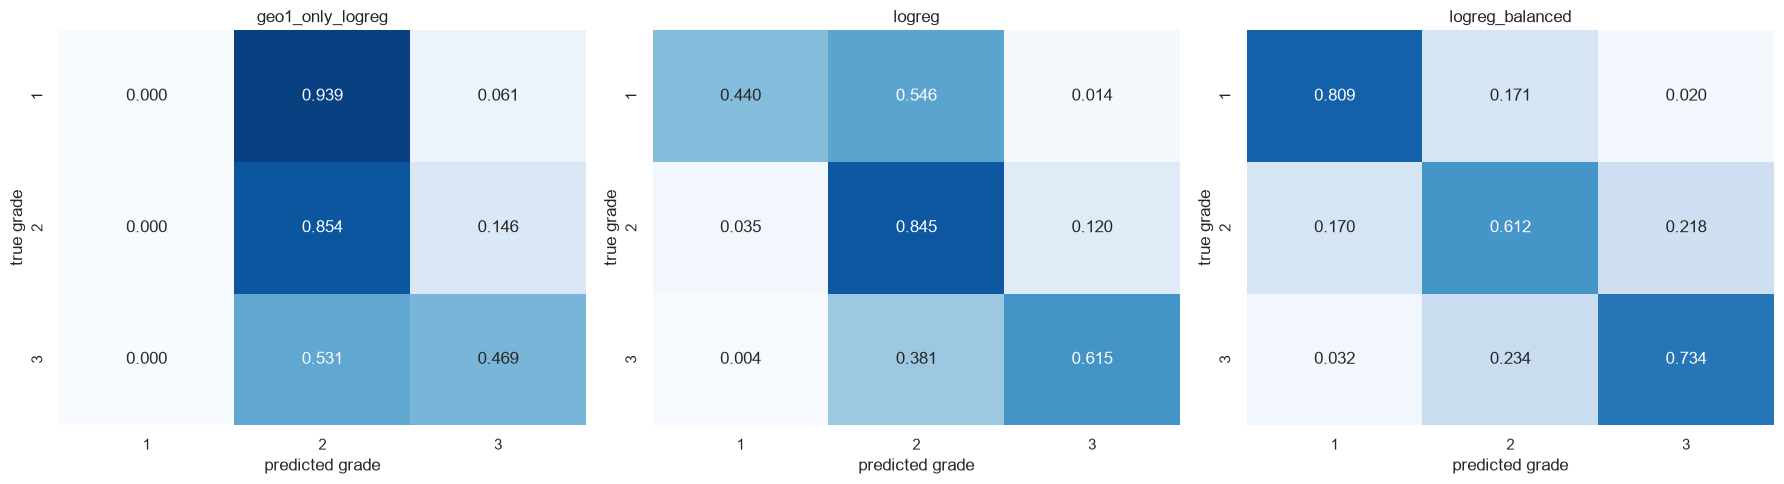

In [19]:
from sklearn.metrics import confusion_matrix

# normalising by true grade, so each row reads as "of the real grade-X buildings, what share went where"
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ["geo1_only_logreg", "logreg", "logreg_balanced"]):
    cm = confusion_matrix(y_train, results[name]["oof_pred"], labels=[1, 2, 3], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=ax,
                xticklabels=[1, 2, 3], yticklabels=[1, 2, 3], cbar=False)
    ax.set_xlabel("predicted grade")
    ax.set_ylabel("true grade")
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Observations**

- Location only: no building is ever predicted as grade 1, and 53.1% of grade-3 buildings are predicted as grade 2.
- Plain logistic regression: 54.6% of grade-1 buildings are predicted as grade 2, and 38.1% of grade-3 buildings as grade 2. Most errors go to the neighbouring grade.
- Balanced weights move errors around rather than removing them: grade 1 recall reaches 80.9%, but 17.0% of grade-2 buildings are now called grade 1 and 21.8% grade 3.

### 5.7 Tree models: random forest

Random forest, LightGBM and XGBoost all use `tree_pre` (the same 41 features). A small wrapper, `LabelSafe`, handles two library quirks so that `run_cv` doesn't need to change: XGBoost expects labels 0/1/2 instead of 1/2/3, and some libraries return predictions as a column instead of a flat array. `min_samples_leaf=3` keeps the forest from memorising single noisy buildings (there are conflicting duplicates).

In [20]:
from sklearn.base import ClassifierMixin
from sklearn.ensemble import RandomForestClassifier

# XGBoost wants labels starting at 0 and CatBoost returns predictions as an (n, 1) column,
# so this wrapper shifts labels where needed and always hands run_cv a flat 1/2/3 array.
# fit_params came in after CatBoost failed sklearn's clone(): its constructor converts cat_features internally,
# so that argument now goes to fit() instead of the constructor
class LabelSafe(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, shift=0, fit_params=None):
        self.estimator = estimator
        self.shift = shift
        self.fit_params = fit_params
    def fit(self, X, y):
        self.est_ = clone(self.estimator).fit(X, np.asarray(y) - self.shift, **(self.fit_params or {}))
        self.classes_ = np.array([1, 2, 3])
        return self
    def predict(self, X):
        return np.asarray(self.est_.predict(X)).ravel().astype(int) + self.shift
    def predict_proba(self, X):
        return self.est_.predict_proba(X)

# min_samples_leaf=3 because fully grown trees on ~167k rows (with duplicate profiles and conflicting labels)
# mostly memorise noise and use a lot of memory
rf = Pipeline([("pre", tree_pre),
               ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=3, max_features="sqrt",
                                              n_jobs=-1, random_state=RANDOM_STATE))])
run_cv(rf, "random_forest")

random_forest
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7448    0.6868  0.6078  0.2578      0.0026    0.4883    0.8615    0.6203  14.6845       0.5457
std     0.0008    0.0017  0.0021  0.0007      0.0003    0.0053    0.0019    0.0044   0.1827       0.0166



{'folds':    accuracy  macro_f1       qwk       mae  severe_err  recall_1  recall_2  recall_3    fit_sec  predict_sec
 0  0.744868  0.687269  0.606888  0.258154    0.003022  0.494650  0.861563  0.618560  14.557022     0.538060
 1  0.745251  0.688019  0.609005  0.257363    0.002614  0.489552  0.859449  0.624794  14.795551     0.569685
 2  0.745827  0.688437  0.610773  0.256667    0.002494  0.491294  0.859913  0.625224  14.526416     0.556009
 3  0.743836  0.684230  0.605564  0.258514    0.002350  0.481095  0.864045  0.615192  14.591626     0.529424
 4  0.744316  0.685806  0.606779  0.258106    0.002422  0.485075  0.862575  0.617959  14.951689     0.535527,
 'oof_pred': array([3, 2, 2, ..., 3, 3, 2], shape=(208480,)),
 'oof_proba': array([[0.00256994, 0.32298427, 0.67444579],
        [0.00305356, 0.62532034, 0.37162611],
        [0.00759955, 0.72646124, 0.26593921],
        ...,
        [0.00341038, 0.33446252, 0.66212709],
        [0.00572223, 0.43124678, 0.56303099],
        [0.0060881

**Observations**

- Random forest: accuracy 0.745, macro F1 0.687, QWK 0.608. That is clearly above logistic regression (macro F1 0.662).
- It is very stable across folds (accuracy standard deviation 0.0008), so even small differences between models can be meaningful, but not the smallest ones.

### 5.8 LightGBM and XGBoost

The two boosters get the same number of trees (500), learning rate (0.05) and subsampling (0.8), so any difference comes from the algorithm and not from one of them getting better settings. These are sensible starting values, not tuned ones; tuning comes in Section 8.

In [21]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# the two boosters get the same number of trees, learning rate and subsampling, so any gap
# comes from the algorithm rather than one of them being handed better settings
lgbm = Pipeline([("pre", tree_pre),
                 ("clf", LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))])
run_cv(lgbm, "lightgbm")

xgb = Pipeline([("pre", tree_pre),
                ("clf", LabelSafe(XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
                                                subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                                                eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1),
                                  shift=1))])
run_cv(xgb, "xgboost")

compare()

lightgbm
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7447    0.6928  0.6129  0.2582      0.0029    0.5246    0.8524    0.6251   7.4501       0.8020
std     0.0012    0.0025  0.0030  0.0016      0.0004    0.0077    0.0030    0.0036   0.1912       0.0245

xgboost
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7454    0.6929  0.6127  0.2577      0.0030    0.5215    0.8538    0.6254  13.5986       0.3378
std     0.0013    0.0024  0.0032  0.0017      0.0005    0.0062    0.0025    0.0040   0.0549       0.0097



,accuracy,macro_f1,qwk,mae,severe_err,recall_1,recall_2,recall_3,fit_sec,predict_sec
dummy_majority,0.5689,0.2417,0.0000,0.4311,0.0000,0.0000,1.0000,0.0000,0.0440,0.0129
dummy_stratified,0.4431,0.3310,-0.0024,0.6209,0.0640,0.0913,0.5659,0.3357,0.0375,0.0167
geo1_only_logreg,0.6426,0.4246,0.3299,0.3633,0.0059,0.0000,0.8537,0.4687,0.8144,0.0175
logreg,0.7291,0.6623,0.5829,0.2737,0.0027,0.4399,0.8452,0.6150,6.0381,0.1375
logreg_balanced,0.6718,0.6458,0.5926,0.3409,0.0127,0.8087,0.6122,0.7338,8.3316,0.1369
random_forest,0.7448,0.6868,0.6078,0.2578,0.0026,0.4883,0.8615,0.6203,14.6845,0.5457
lightgbm,0.7447,0.6928,0.6129,0.2582,0.0029,0.5246,0.8524,0.6251,7.4501,0.8020
xgboost,0.7454,0.6929,0.6127,0.2577,0.0030,0.5215,0.8538,0.6254,13.5986,0.3378


**Observations**

| | accuracy | macro F1 | QWK | recall grade 1 | fit per fold |
|---|---|---|---|---|---|
| logistic regression | 0.729 | 0.662 | 0.583 | 0.440 | 6.0 s |
| random forest | 0.745 | 0.687 | 0.608 | 0.488 | 14.7 s |
| LightGBM | 0.745 | 0.693 | 0.613 | 0.525 | 7.5 s |
| XGBoost | 0.745 | 0.693 | 0.613 | 0.522 | 13.6 s |

- All tree models beat logistic regression clearly (about +1.6 points accuracy and +0.025-0.03 macro F1), which fits the non-monotonic patterns seen in the EDA.
- LightGBM and XGBoost are effectively tied (macro F1 0.6928 vs 0.6929, far below the fold-to-fold spread of about 0.002). LightGBM trains in roughly half the time.
- The boosters beat the random forest mainly on grade 1 (recall about 0.52 vs 0.49).
- Grade-1 recall is still only about 0.5 even for the best models, so the imbalance problem is not solved yet.

### 5.9 CatBoost attempt (not continued)

The idea was to compare our own cross-fitted target encoding against CatBoost's built-in handling of categories. The run failed before training started: sklearn's `clone()` refuses to copy a `CatBoostClassifier`, because CatBoost's constructor converts the `cat_features` list internally and the copy check finds a different object (error below). I kept the cell as a record of the problem.

In [32]:
from catboost import CatBoostClassifier

cb_cat_features = cat_cols + geo_cols

# CatBoost does its own ordered target statistics on categories, so it gets the raw columns.
# the 995 age code is handled the same way in spirit (flag + treat the value as missing), with nothing learned from data here
def catboost_prep(X):
    X = X.copy()
    X["age_unknown"] = (X["age"] == 995).astype(int)
    X["age"] = X["age"].where(X["age"] != 995, np.nan).astype(float)
    for c in cb_cat_features:
        X[c] = X[c].astype(str).astype(object)      # pandas 3 'str' dtype turned into plain python strings for CatBoost
    return X

catb = Pipeline([("prep", FunctionTransformer(catboost_prep)),
                 ("clf", LabelSafe(CatBoostClassifier(iterations=800, learning_rate=0.1, depth=6,
                                                      loss_function="MultiClass", cat_features=cb_cat_features,
                                                      random_seed=RANDOM_STATE, thread_count=-1, verbose=0),
                                   shift=0))])
run_cv(catb, "catboost_native")

compare()

RuntimeError: Cannot clone object CatBoostClassifier(cat_features=['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id'], depth=6, iterations=800, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features

Instead of patching CatBoost, I answered the same question ("does built-in category handling beat target encoding?") with LightGBM's native categorical support in the next section. It uses the same library and the same settings as the LightGBM run above, so it is a cleaner comparison, and it avoided a slow extra library. CatBoost is therefore not part of the comparison. The `fit_params` option added to `LabelSafe` came out of this error: settings like category lists are passed at fit time instead of in the constructor.

## 6. Alternative encodings and ordinal approaches

### 6.1 LightGBM with native categorical handling

No target encoding here: categories become integer codes and the raw geo ids go in as categories, so LightGBM groups them itself when searching for splits. Settings are the same as the LightGBM run in 5.8.

In [22]:
# same settings as the 'lightgbm' run, kept in one place so the ordinal variants below use them too
LGB_PARAMS = dict(n_estimators=500, learning_rate=0.05, num_leaves=63, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

# no target encoding here: categories become integer codes and the raw geo ids go in as categories,
# so LightGBM groups them itself when it looks for splits
native_pre = ColumnTransformer([
    ("age", AgeCleaner(), ["age"]),                                                    # columns 0-1
    ("num", "passthrough", num_log + num_plain),                                       # 2-5
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),  # 6-13
    ("geo_raw", "passthrough", geo_cols),                                              # 14-16
    ("bin", "passthrough", bin_cols),
])
native_cat_idx = list(range(6, 17))

lgbm_native = Pipeline([("pre", native_pre),
                        ("clf", LabelSafe(LGBMClassifier(**LGB_PARAMS), shift=0,
                                          fit_params={"categorical_feature": native_cat_idx}))])
run_cv(lgbm_native, "lightgbm_native_cat");

lightgbm_native_cat
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7477    0.7016  0.6209  0.2567      0.0045    0.5634    0.8371    0.6490  36.2553       7.3827
std     0.0017    0.0025  0.0026  0.0015      0.0004    0.0058    0.0012    0.0035   0.3093       0.2004



**Observations**

- Macro F1 0.7016 vs 0.6928 for the target-encoded LightGBM, with accuracy 0.748 and grade-1 recall 0.563 (vs 0.525). The gain of about 0.009 is roughly 3.5 times the fold standard deviation (0.0025), so it is unlikely to be noise.
- It is not free: severe errors rise from 0.29% to 0.45%, training is about 5× slower (36.3 s per fold) and prediction about 9× slower (7.4 s), because splits on `geo_level_3_id` have to sort through thousands of categories.

### 6.2 Ordinal approach 1: regression with cut points

So far every model treats the grades as three unrelated classes. Here the grade is predicted as a number with a LightGBM regressor and then cut into 1/2/3. Squared error punishes a 1↔3 mistake four times more than a 1↔2 mistake, so the order is built into the training itself.

Two versions: fixed cut points at 1.5 and 2.5, and cut points learned for macro F1. The learned cut points come from out-of-fold predictions **inside each training fold** (3 inner folds), so the validation fold is never used to choose them.

In [23]:
from lightgbm import LGBMRegressor

# plain numpy macro F1, because the cut-point search calls it a few hundred times and f1_score is slow for that
def fast_macro_f1(y, p):
    scores = []
    for k in (1, 2, 3):
        tp = np.sum((p == k) & (y == k)); fp = np.sum((p == k) & (y != k)); fn = np.sum((p != k) & (y == k))
        scores.append(2 * tp / (2 * tp + fp + fn) if (tp + fp + fn) else 0.0)
    return np.mean(scores)

# predicting the grade as a number keeps the 1<2<3 order in the loss itself.
# with search=True the two cut points come from inner out-of-fold predictions on the training fold only
class ThresholdedRegressor(BaseEstimator, ClassifierMixin):
    def __init__(self, regressor, search=True, inner_splits=3, random_state=RANDOM_STATE):
        self.regressor = regressor
        self.search = search
        self.inner_splits = inner_splits
        self.random_state = random_state
    def fit(self, X, y):
        y = np.asarray(y)
        self.thresholds_ = np.array([1.5, 2.5])
        if self.search:
            inner = np.zeros(len(y))
            skf_in = StratifiedKFold(self.inner_splits, shuffle=True, random_state=self.random_state)
            for tr, va in skf_in.split(X, y):
                inner[va] = clone(self.regressor).fit(X[tr], y[tr]).predict(X[va])
            best = (-1.0, 1.5, 2.5)
            for t1 in np.arange(1.20, 2.21, 0.05):
                for t2 in np.arange(max(t1 + 0.05, 2.00), 2.91, 0.05):
                    f = fast_macro_f1(y, np.digitize(inner, [t1, t2]) + 1)
                    if f > best[0]:
                        best = (f, t1, t2)
            self.thresholds_ = np.array(best[1:])
            print(f"    learned cut points: {self.thresholds_.round(2)}")
        self.reg_ = clone(self.regressor).fit(X, y)
        self.classes_ = np.array([1, 2, 3])
        return self
    def predict(self, X):
        return np.digitize(self.reg_.predict(X), self.thresholds_) + 1

lgbm_reg_fixed = Pipeline([("pre", tree_pre), ("clf", ThresholdedRegressor(LGBMRegressor(**LGB_PARAMS), search=False))])
run_cv(lgbm_reg_fixed, "lgbm_regression_fixed_cuts");

lgbm_reg_tuned = Pipeline([("pre", tree_pre), ("clf", ThresholdedRegressor(LGBMRegressor(**LGB_PARAMS), search=True))])
run_cv(lgbm_reg_tuned, "lgbm_regression_learned_cuts");

lgbm_regression_fixed_cuts
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7409    0.6764  0.5991  0.2607      0.0015    0.4485    0.8668    0.6111   2.6419       0.2889
std     0.0005    0.0019  0.0016  0.0006      0.0003    0.0081    0.0029    0.0038   0.0982       0.0118

    learned cut points: [1.7  2.45]
    learned cut points: [1.7  2.45]
    learned cut points: [1.7 2.4]
    learned cut points: [1.7  2.45]
    learned cut points: [1.7  2.45]
lgbm_regression_learned_cuts
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7360    0.6986  0.6290  0.2673      0.0033    0.6378    0.7954    0.6633  10.1573       0.2849
std     0.0017    0.0013  0.0033  0.0021      0.0004    0.0057    0.0146    0.0218   0.3171       0.0069



**Observations**

- Fixed cut points give the **lowest severe-error rate of any model so far (0.15%)**, half that of the classifiers, and the fastest training (2.6 s per fold). The cost is that grade 1 is rarely predicted (recall 0.449, macro F1 0.676).
- The learned cut points are very stable: [1.70, 2.45] in four folds and [1.70, 2.40] in one.
- With learned cuts, QWK reaches 0.629 (the best so far) and grade-1 recall 0.638, with macro F1 0.699. Most of the gain comes from moving the lower cut from 1.5 to 1.7, so more buildings are called grade 1. In other words, it is mostly a change in **how predictions are turned into grades**, not a better model. Section 7 gives every model the same chance.

### 6.3 Ordinal approach 2: cumulative binary models (Frank and Hall)

Two binary LightGBM models answer the ordered questions "worse than grade 1?" and "worse than grade 2?", and their probabilities are combined into three class probabilities. Because the two models are trained separately, P(grade > 2) can occasionally exceed P(grade > 1); that case is clipped.

In [24]:
# two yes/no questions that follow the order of the grades: "worse than grade 1?" and "worse than grade 2?"
class CumulativeOrdinal(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y):
        y = np.asarray(y)
        self.models_ = [clone(self.estimator).fit(X, (y > k).astype(int)) for k in (1, 2)]
        self.classes_ = np.array([1, 2, 3])
        return self
    def predict_proba(self, X):
        p_gt1 = self.models_[0].predict_proba(X)[:, 1]
        p_gt2 = self.models_[1].predict_proba(X)[:, 1]
        # the two models are trained separately, so P(>2) can come out slightly above P(>1); clipping that case
        p = np.column_stack([1 - p_gt1, np.clip(p_gt1 - p_gt2, 0, None), p_gt2])
        return p / p.sum(axis=1, keepdims=True)
    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1) + 1

lgbm_cumulative = Pipeline([("pre", tree_pre), ("clf", CumulativeOrdinal(LGBMClassifier(**LGB_PARAMS)))])
run_cv(lgbm_cumulative, "lgbm_cumulative_ordinal");

compare()

lgbm_cumulative_ordinal
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7443    0.6931  0.6125  0.2587      0.0030    0.5288    0.8517    0.6237   5.9316       0.4974
std     0.0013    0.0029  0.0035  0.0016      0.0005    0.0093    0.0023    0.0036   1.3101       0.0260



,accuracy,macro_f1,qwk,mae,severe_err,recall_1,recall_2,recall_3,fit_sec,predict_sec
dummy_majority,0.5689,0.2417,0.0000,0.4311,0.0000,0.0000,1.0000,0.0000,0.0440,0.0129
dummy_stratified,0.4431,0.3310,-0.0024,0.6209,0.0640,0.0913,0.5659,0.3357,0.0375,0.0167
geo1_only_logreg,0.6426,0.4246,0.3299,0.3633,0.0059,0.0000,0.8537,0.4687,0.8144,0.0175
logreg,0.7291,0.6623,0.5829,0.2737,0.0027,0.4399,0.8452,0.6150,6.0381,0.1375
logreg_balanced,0.6718,0.6458,0.5926,0.3409,0.0127,0.8087,0.6122,0.7338,8.3316,0.1369
random_forest,0.7448,0.6868,0.6078,0.2578,0.0026,0.4883,0.8615,0.6203,14.6845,0.5457
lightgbm,0.7447,0.6928,0.6129,0.2582,0.0029,0.5246,0.8524,0.6251,7.4501,0.8020
xgboost,0.7454,0.6929,0.6127,0.2577,0.0030,0.5215,0.8538,0.6254,13.5986,0.3378
lightgbm_native_cat,0.7477,0.7016,0.6209,0.2567,0.0045,0.5634,0.8371,0.6490,36.2553,7.3827
lgbm_regression_fixed_cuts,0.7409,0.6764,0.5991,0.2607,0.0015,0.4485,0.8668,0.6111,2.6419,0.2889


**Observation.** Macro F1 0.6931, practically identical to plain multiclass LightGBM (0.6928). Splitting the problem into ordered binary questions adds nothing here, so I didn't take it further.

### 6.4 Per-grade target encoding

My first guess for why native categories beat the target encoding: one mean grade per area hides how the grades are spread (an area split between grades 1 and 3 can have the same mean as an area of all grade 2). `TargetEncoder(target_type="multiclass")` keeps one rate per grade instead, three columns per geo level.

In [25]:
# the native-category model beat the mean-grade encoding, and my guess is that one number per area hides
# how its grades are spread. multiclass encoding keeps one rate per grade instead (3 columns per geo level)
tree_pre_mc = clone(tree_pre).set_params(geo_te=TargetEncoder(target_type="multiclass", cv=te_cv))

p = clone(tree_pre_mc)
print("features with per-grade encoding:", p.fit_transform(X_train.iloc[FOLDS[0][0]], y_train[FOLDS[0][0]]).shape[1])

lgbm_te_mc = Pipeline([("pre", tree_pre_mc), ("clf", LGBMClassifier(**LGB_PARAMS))])
run_cv(lgbm_te_mc, "lightgbm_te_multiclass");

features with per-grade encoding: 45
lightgbm_te_multiclass
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7460    0.6949  0.6143  0.2576      0.0035    0.5316    0.8498    0.6311   7.4746       0.7618
std     0.0012    0.0015  0.0024  0.0014      0.0002    0.0033    0.0024    0.0056   0.0434       0.0322



**Observations**

- 45 features (41 − 2 mean-grade columns + 6 per-grade columns).
- Macro F1 0.6949 vs 0.6928 for the mean-grade encoding, about one fold standard deviation. It closes only about a quarter of the gap to native categories (0.7016), so my guess was mostly wrong.
- A more likely explanation: target encoding gives each area one fixed value, while native categorical splits can group areas differently in different parts of a tree (for example, depending on construction type). That is a hypothesis I did not test directly.
- It keeps the speed of the target-encoded model (7.5 s fit, 0.8 s predict), so it becomes the target-encoded representative from here on.

## 7. Decision rule and first full comparison

### 7.1 The same decision rule for every model

The learned cut points in 6.2 showed that the way probabilities are turned into grades matters a lot. To compare fairly, every model with probabilities gets the same treatment: P(grade 1) and P(grade 3) are multiplied by weights `w1` and `w3`, and the largest value is taken. The weights are searched to maximise macro F1.

To avoid leakage, the weights for fold *k* are chosen only on the out-of-fold predictions of the **other four folds** and then applied to fold *k*. Nothing is retrained; only stored probabilities are reused.

In [26]:
# the learned cut points showed that the decision rule matters a lot, so every model with probabilities gets
# the same treatment: scale P(grade 1) and P(grade 3) by weights, then take the largest.
# weights for fold k are chosen only on the out-of-fold predictions of the other four folds, then applied to fold k
fold_id = np.empty(len(y_train), dtype=int)
for k, (_, va) in enumerate(FOLDS):
    fold_id[va] = k

W1_GRID = np.arange(0.5, 4.01, 0.25)
W3_GRID = np.arange(0.5, 2.51, 0.1)

def apply_rule(P, w1, w3):
    return (P * np.array([w1, 1.0, w3])).argmax(axis=1) + 1

def tune_rule(P, y):
    best = (-1.0, 1.0, 1.0)
    for w1 in W1_GRID:
        for w3 in W3_GRID:
            f = fast_macro_f1(y, apply_rule(P, w1, w3))
            if f > best[0]:
                best = (f, w1, w3)
    return best[1], best[2]

prob_models = [n for n in results
               if not n.startswith("dummy") and "+rule" not in n and not np.isnan(results[n]["oof_proba"]).any()]
print("tuning:", prob_models)

rule_weights = {}
for name in prob_models:
    P = results[name]["oof_proba"]
    tuned_pred = np.zeros(len(y_train), dtype=int)
    rows, ws = [], []
    for k in range(5):
        w1, w3 = tune_rule(P[fold_id != k], y_train[fold_id != k])
        ws.append((w1, w3))
        tuned_pred[fold_id == k] = apply_rule(P[fold_id == k], w1, w3)
        rows.append({**ordinal_metrics(y_train[fold_id == k], tuned_pred[fold_id == k]),
                     "fit_sec": results[name]["folds"]["fit_sec"].iloc[k],
                     "predict_sec": results[name]["folds"]["predict_sec"].iloc[k]})
    results[f"{name}+rule"] = {"folds": pd.DataFrame(rows), "oof_pred": tuned_pred, "oof_proba": P}
    rule_weights[name] = ws
    print(f"{name:28} weights per fold (w1, w3): {[(float(a), float(b)) for a, b in ws]}")

tuning: ['geo1_only_logreg', 'logreg', 'logreg_balanced', 'random_forest', 'lightgbm', 'xgboost', 'lightgbm_native_cat', 'lgbm_cumulative_ordinal', 'lightgbm_te_multiclass']
geo1_only_logreg             weights per fold (w1, w3): [(1.75, 1.0999999999999999), (1.75, 1.0999999999999999), (1.75, 1.0999999999999999), (1.75, 1.0999999999999999), (1.75, 1.0999999999999999)]
logreg                       weights per fold (w1, w3): [(2.25, 1.0999999999999999), (2.25, 1.1999999999999997), (2.25, 1.2999999999999998), (2.25, 1.0999999999999999), (2.25, 1.0999999999999999)]
logreg_balanced              weights per fold (w1, w3): [(0.5, 0.7), (0.5, 0.7), (0.5, 0.7), (0.5, 0.7), (0.5, 0.7)]
random_forest                weights per fold (w1, w3): [(1.75, 1.1999999999999997), (1.75, 1.1999999999999997), (1.75, 1.1999999999999997), (1.75, 1.2999999999999998), (1.75, 1.1999999999999997)]
lightgbm                     weights per fold (w1, w3): [(1.75, 1.2999999999999998), (1.75, 1.2999999999999998), (1.75

**Observations**

- The chosen weights are very stable: almost every tree model settles on `w1 = 1.75` and `w3 = 1.2-1.3` in every fold. Taking the most likely class consistently under-predicts both outer grades, especially grade 1.
- Logistic regression needs a stronger push towards grade 1 (`w1 = 2.25`).
- The balanced logistic regression gets weights **below 1** (0.5 and 0.7), meaning the rule partly undoes the class weighting. That independently confirms that balanced weights over-corrected in 5.4.

### 7.2 Plain vs tuned decision rule, all models

Mean over the 5 folds, with the fold standard deviation of macro F1 so small differences can be judged against the noise.

In [27]:
cols = ["accuracy", "macro_f1", "qwk", "mae", "severe_err", "recall_1", "recall_2", "recall_3", "fit_sec", "predict_sec"]
table = compare()[cols]

# also showing the spread across folds for macro F1, so small differences can be judged against the noise
table.insert(2, "macro_f1_std", pd.Series({n: results[n]["folds"]["macro_f1"].std() for n in table.index}).round(4))
print(table.sort_values("macro_f1", ascending=False).to_string())

                              accuracy  macro_f1  macro_f1_std     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
lightgbm_native_cat+rule        0.7420    0.7081        0.0014  0.6325  0.2644      0.0064    0.6760    0.7878    0.6830  36.2553       7.3827
lightgbm_te_multiclass+rule     0.7402    0.7053        0.0012  0.6294  0.2657      0.0060    0.6661    0.7917    0.6741   7.4746       0.7618
xgboost+rule                    0.7389    0.7036        0.0014  0.6292  0.2664      0.0053    0.6660    0.7940    0.6663  13.5986       0.3378
lightgbm+rule                   0.7380    0.7035        0.0017  0.6299  0.2673      0.0052    0.6594    0.7851    0.6805   7.4501       0.8020
lgbm_cumulative_ordinal+rule    0.7378    0.7035        0.0011  0.6296  0.2674      0.0052    0.6590    0.7851    0.6800   5.9316       0.4974
random_forest+rule              0.7397    0.7031        0.0011  0.6293  0.2654      0.0051    0.6551    0.7974    0.6662  14.6845       0.5457

**Observations**

- The tuned rule improves every tree model, but by different amounts: **+0.0065 to +0.0163 macro F1** (smallest for native-category LightGBM, largest for the random forest) and +0.012 to +0.022 QWK. Grade-1 recall rises from 0.49-0.56 to 0.66-0.68. The price is 0.5-0.7 points of accuracy and more severe errors (from 0.26-0.45% to 0.51-0.64%).
- With the same rule, the tree models end up close together. The target-encoded models (LightGBM, XGBoost, random forest, cumulative) are all within about 0.002 of each other (0.7031-0.7053). The random forest's earlier gap to the boosters was mostly the decision rule, not the model.
- Native categories keep a lead (0.7081), about 2 fold standard deviations above the next model (0.7053), with the highest severe-error rate (0.64%) and the slowest predictions.
- Logistic regression with the rule reaches 0.6796, still about 0.024 behind every tree model. The clearest gap in the table is between model **types**, not between individual tree models.
- Regression with learned cut points (0.6986) has the lowest severe-error rate among the stronger models (0.33%), which is a different trade-off worth keeping in the comparison.

### 7.3 Which way do the severe errors go?

A destroyed building predicted as grade 1 matters more for inspection than a low-damage building predicted as grade 3, so I count the two directions separately for the strongest candidates (out-of-fold, training data).

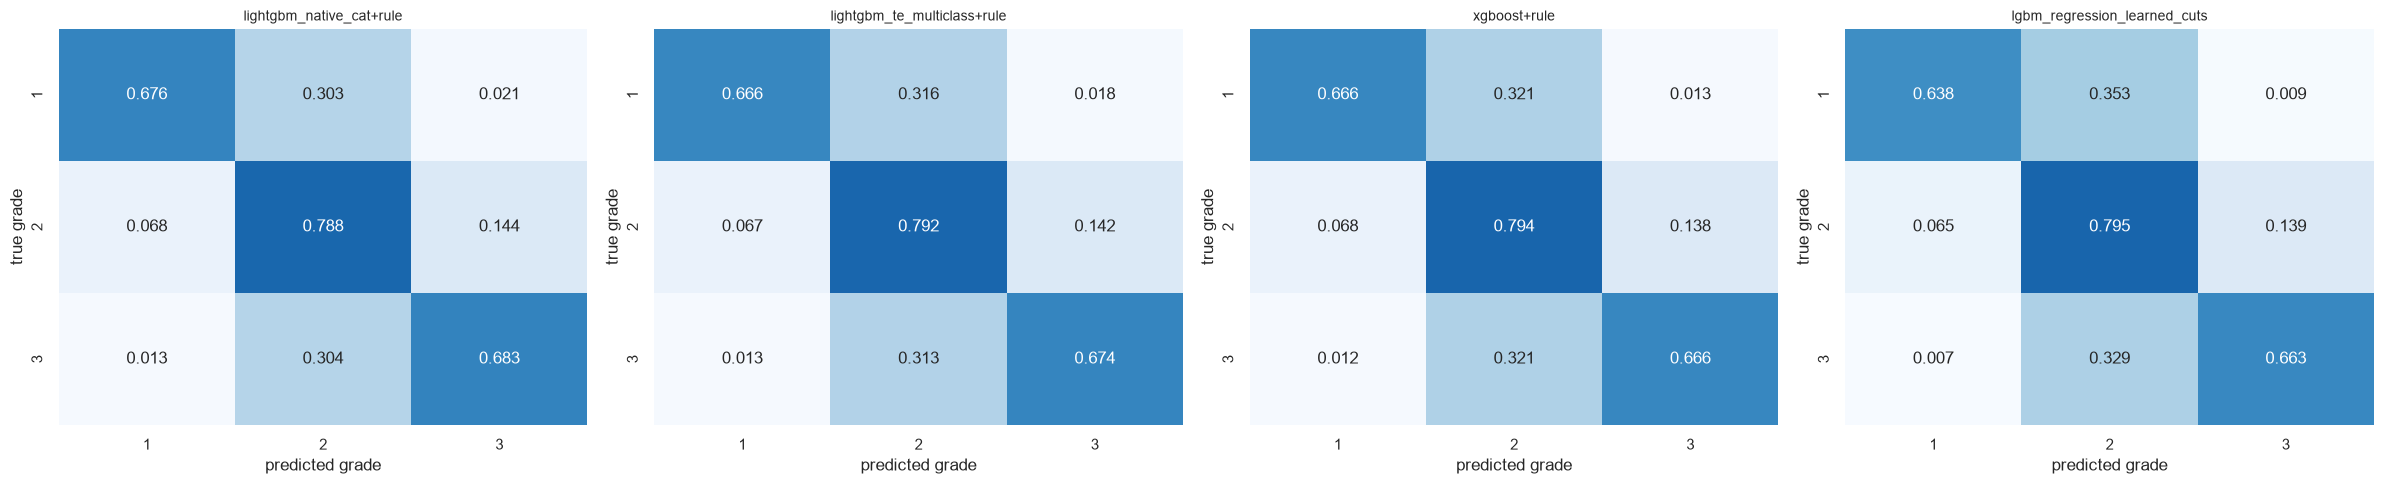

                              true3_pred1  true1_pred3  true3_pred_below3_share
model                                                                          
lightgbm_native_cat+rule              922          416                   0.3170
lightgbm_te_multiclass+rule           874          369                   0.3259
xgboost+rule                          854          261                   0.3337
lgbm_regression_learned_cuts          517          181                   0.3367


In [28]:
# the severe errors are the costly ones, so I want to see which direction they go:
# a destroyed building predicted as grade 1 matters more for inspection than the other way round
finalists = ["lightgbm_native_cat+rule", "lightgbm_te_multiclass+rule", "xgboost+rule", "lgbm_regression_learned_cuts"]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, name in zip(axes, finalists):
    cm = confusion_matrix(y_train, results[name]["oof_pred"], labels=[1, 2, 3], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=ax,
                xticklabels=[1, 2, 3], yticklabels=[1, 2, 3], cbar=False)
    ax.set_xlabel("predicted grade"); ax.set_ylabel("true grade"); ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

rows = []
for name in finalists:
    pred = results[name]["oof_pred"]
    rows.append({"model": name,
                 "true3_pred1": int(((y_train == 3) & (pred == 1)).sum()),
                 "true1_pred3": int(((y_train == 1) & (pred == 3)).sum()),
                 "true3_pred_below3_share": ((y_train == 3) & (pred < 3)).sum() / (y_train == 3).sum()})
print(pd.DataFrame(rows).set_index("model").round(4).to_string())

**Observations**

| model | true 3 → predicted 1 | true 1 → predicted 3 | grade-3 buildings predicted below 3 |
|---|---|---|---|
| LightGBM native + rule | 922 | 416 | 31.7% |
| LightGBM per-grade TE + rule | 874 | 369 | 32.6% |
| XGBoost + rule | 854 | 261 | 33.4% |
| regression, learned cuts | **517** | **181** | 33.7% |

- The confusion matrices look very similar across models: about two thirds of each outer grade is recognised, and most errors go to grade 2.
- The regression model makes the fewest severe errors in both directions.
- For every model, roughly a third of destroyed buildings are predicted as grade 2. Section 12 looks at how probabilities can be used to reach more of them.

## 8. Hyperparameter tuning of the finalists

Finalists going into tuning:

1. **LightGBM with native categories**, the best score so far, to see whether its lead survives tuning.
2. **LightGBM with per-grade target encoding**, the best of the fast models.
3. **XGBoost with the same per-grade target encoding**, so the comparison between the two boosters stays fair.

All three get the same search: 20 random candidates, the same 3 of the 5 folds (to keep the cost manageable), and the same objective, **log loss**. Tuning for probability quality and re-tuning the decision rule on top keeps two questions separate: how good the model is, and where the decision boundaries go.

I first checked whether Optuna was available.

In [29]:
try:
    import optuna
    print("optuna:", optuna.__version__)
except ImportError:
    print("optuna: not installed")

optuna: not installed


Optuna is not installed and I chose to stay with scikit-learn, so the searches use `RandomizedSearchCV` with fixed folds and a fixed sampling seed.

### 8.1 Search: LightGBM with per-grade target encoding

The default-settings models were already scored on exactly these three folds, so their log loss is read from the stored out-of-fold probabilities and printed next to the search results as a fair "before". The search space is fairly wide around the defaults (500 trees, learning rate 0.05, 63 leaves, 0.8 subsampling).

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss
from scipy.stats import randint, uniform, loguniform

TUNE_FOLDS = FOLDS[:3]      # searching on 3 of the 5 folds to keep the cost reasonable
N_ITER = 20                 # same budget for every finalist
tuning = {}

# the default-settings models were already scored on these exact folds, so their log loss comes
# straight from the stored out-of-fold probabilities, with nothing refitted
def baseline_logloss(name):
    P = results[name]["oof_proba"]
    return np.mean([log_loss(y_train[va], P[va], labels=[1, 2, 3]) for _, va in TUNE_FOLDS])

def tune(pipe, space, name):
    t0 = time.time()
    rs = RandomizedSearchCV(pipe, space, n_iter=N_ITER, scoring="neg_log_loss", cv=TUNE_FOLDS, refit=False,
                            random_state=RANDOM_STATE, n_jobs=1, verbose=2, error_score="raise")
    rs.fit(X_train, y_train)
    cv = pd.DataFrame(rs.cv_results_)
    cv["mean_logloss"], cv["std_logloss"] = -cv["mean_test_score"], cv["std_test_score"]
    cv = cv.sort_values("mean_logloss")
    tuning[name] = {"cv": cv, "best_params": rs.best_params_}
    print(f"\n{name}: {N_ITER} candidates in {(time.time() - t0) / 60:.1f} min")
    print(f"default settings, same folds: log loss {baseline_logloss(name):.4f}")
    show = [c for c in cv.columns if c.startswith("param_")] + ["mean_logloss", "std_logloss", "mean_fit_time"]
    print(cv[show].head(5).infer_objects().round(4).to_string(index=False))

# fairly wide ranges around the defaults used so far (500 trees, lr 0.05, 63 leaves, 0.8 subsampling)
lgb_space = {
    "clf__n_estimators": randint(300, 1201),
    "clf__learning_rate": loguniform(0.02, 0.15),
    "clf__num_leaves": randint(31, 256),
    "clf__min_child_samples": randint(10, 201),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.4, 0.6),
    "clf__reg_lambda": loguniform(1e-3, 10),
}
tune(lgbm_te_mc, lgb_space, "lightgbm_te_multiclass")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END clf__colsample_bytree=0.6247240713084175, clf__learning_rate=0.1358198535217987, clf__min_child_samples=116, clf__n_estimators=371, clf__num_leaves=219, clf__reg_lambda=0.24400607090817547, clf__subsample=0.7783331011414365; total time=  15.1s
[CV] END clf__colsample_bytree=0.6247240713084175, clf__learning_rate=0.1358198535217987, clf__min_child_samples=116, clf__n_estimators=371, clf__num_leaves=219, clf__reg_lambda=0.24400607090817547, clf__subsample=0.7783331011414365; total time=  14.3s
[CV] END clf__colsample_bytree=0.6247240713084175, clf__learning_rate=0.1358198535217987, clf__min_child_samples=116, clf__n_estimators=371, clf__num_leaves=219, clf__reg_lambda=0.24400607090817547, clf__subsample=0.7783331011414365; total time=  14.2s
[CV] END clf__colsample_bytree=0.45998494949080176, clf__learning_rate=0.05045461670694084, clf__min_child_samples=126, clf__n_estimators=399, clf__num_leaves=134, clf__reg_lambda=

**Observations** (22.4 minutes)

- Default settings: log loss 0.5692. Best candidate: **0.5676** (1,024 trees, 238 leaves, learning rate 0.022). Runner-up: 0.5687 (399 trees, 134 leaves, learning rate 0.050).
- The gain is only 0.0016, less than two fold standard deviations, and all top five candidates are within 0.002 of the default. Within these ranges the settings hardly matter: the data and features set the ceiling, which is consistent with the conflicting duplicate labels found in 2.1.
- The best candidate trains about 3.5× slower than the runner-up for 0.0011 lower log loss, so both are carried into the final comparison.

### 8.2 Search: XGBoost with per-grade target encoding

The earlier XGBoost run used the mean-grade encoding, so XGBoost first gets a default run on the per-grade features. Without that there would be no fair "before" for the tuned version.

In [31]:
# the earlier xgboost run used the mean-grade encoding, so it gets a default run on the per-grade features
# first. without that there's no fair "before" to compare the tuned version against
xgb_te_mc = Pipeline([("pre", tree_pre_mc),
                      ("clf", LabelSafe(XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
                                                      subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                                                      eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1),
                                        shift=1))])
run_cv(xgb_te_mc, "xgboost_te_multiclass");

xgb_space = {
    "clf__estimator__n_estimators": randint(300, 1201),
    "clf__estimator__learning_rate": loguniform(0.02, 0.15),
    "clf__estimator__max_depth": randint(4, 13),
    "clf__estimator__min_child_weight": loguniform(0.5, 20),
    "clf__estimator__subsample": uniform(0.6, 0.4),
    "clf__estimator__colsample_bytree": uniform(0.4, 0.6),
    "clf__estimator__reg_lambda": loguniform(1e-3, 10),
}
tune(xgb_te_mc, xgb_space, "xgboost_te_multiclass")

xgboost_te_multiclass
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7465    0.6954  0.6149  0.2571      0.0036    0.5308    0.8499    0.6329  15.6624       0.3401
std     0.0011    0.0017  0.0022  0.0012      0.0003    0.0039    0.0017    0.0043   0.2482       0.0152

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END clf__estimator__colsample_bytree=0.6247240713084175, clf__estimator__learning_rate=0.1358198535217987, clf__estimator__max_depth=11, clf__estimator__min_child_weight=4.550475813202184, clf__estimator__n_estimators=914, clf__estimator__reg_lambda=0.06071989493441298, clf__estimator__subsample=0.6399899663272012; total time=  46.1s
[CV] END clf__estimator__colsample_bytree=0.6247240713084175, clf__estimator__learning_rate=0.1358198535217987, clf__estimator__max_depth=11, clf__estimator__min_child_weight=4.550475813202184, clf__estimator__n_estimators=914, clf__estimator__reg_lambda=0.060

C:\Users\sahup\anaconda3\anaconda117\envs\anaconda-tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\sahup\anaconda3\anaconda117\envs\anaconda-tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\sahup\anaconda3\anaconda117\envs\anaconda-tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


**Observations**

- Default XGBoost on the per-grade features: macro F1 0.6954, the same as LightGBM on the same features (0.6949), but about 2× slower to train (15.7 s vs 7.5 s per fold). Across three different feature setups the two boosters keep tying.
- The search took 32.4 minutes. The `UserWarning` lines come from XGBoost returning float32 probabilities whose rows sum to 1 only up to about 1e-7; the effect on log loss is negligible (it is handled explicitly in the final table in 8.6).

In [37]:
# the summary of this search never printed in the earlier session, so it's read back from the stored results
cv = tuning["xgboost_te_multiclass"]["cv"]
print(f"xgboost_te_multiclass: default settings, same folds: log loss {baseline_logloss('xgboost_te_multiclass'):.4f}")
show = [c for c in cv.columns if c.startswith("param_")] + ["mean_logloss", "std_logloss", "mean_fit_time"]
print(cv[show].head(5).infer_objects().round(4).to_string(index=False))

xgboost_te_multiclass: default settings, same folds: log loss 0.5683
 param_clf__estimator__colsample_bytree  param_clf__estimator__learning_rate  param_clf__estimator__max_depth  param_clf__estimator__min_child_weight  param_clf__estimator__n_estimators  param_clf__estimator__reg_lambda  param_clf__estimator__subsample  mean_logloss  std_logloss  mean_fit_time
                                 0.4992                               0.0206                               12                                  8.6328                                 947                            0.0011                           0.9262        0.5669       0.0011        44.5380
                                 0.7645                               0.0282                               10                                  0.5251                                 900                            7.2867                           0.9234        0.5678       0.0009        42.1490
                                 0.9355       

C:\Users\sahup\anaconda3\anaconda117\envs\anaconda-tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\sahup\anaconda3\anaconda117\envs\anaconda-tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\sahup\anaconda3\anaconda117\envs\anaconda-tensorflow\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


**Observation.** Default log loss 0.5683, best candidate **0.5669** (947 trees, depth 12, learning rate 0.021). Again a small gain (0.0014) for a model that is now slower to train.

### 8.3 Search: LightGBM with native categories

The same ranges as the target-encoded LightGBM, plus three settings that control how LightGBM smooths and groups categories (`cat_smooth`, `min_data_per_group`, `cat_l2`). These matter most for the roughly 11,000 level-3 areas.

This search was the most expensive part of the project. Its first run was lost when the laptop went to sleep and the kernel froze (see Challenges, Section 15), so the result below is from a clean re-run.

In [32]:
# same ranges as the target-encoded LightGBM, plus the three settings that control how LightGBM
# smooths and groups categories when it splits on them (these matter most for the ~11k geo_level_3 ids)
native_space = {k.replace("clf__", "clf__estimator__"): v for k, v in lgb_space.items()}
native_space.update({
    "clf__estimator__cat_smooth": loguniform(1, 100),
    "clf__estimator__min_data_per_group": randint(20, 301),
    "clf__estimator__cat_l2": loguniform(1, 50),
})
tune(lgbm_native, native_space, "lightgbm_native_cat")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END clf__estimator__cat_l2=4.32845022129388, clf__estimator__cat_smooth=79.69454818643933, clf__estimator__colsample_bytree=0.839196365086843, clf__estimator__learning_rate=0.06681790353582674, clf__estimator__min_child_samples=112, clf__estimator__min_data_per_group=141, clf__estimator__n_estimators=766, clf__estimator__num_leaves=245, clf__estimator__reg_lambda=0.0017073967431528124, clf__estimator__subsample=0.9464704583099741; total time=  53.6s
[CV] END clf__estimator__cat_l2=4.32845022129388, clf__estimator__cat_smooth=79.69454818643933, clf__estimator__colsample_bytree=0.839196365086843, clf__estimator__learning_rate=0.06681790353582674, clf__estimator__min_child_samples=112, clf__estimator__min_data_per_group=141, clf__estimator__n_estimators=766, clf__estimator__num_leaves=245, clf__estimator__reg_lambda=0.0017073967431528124, clf__estimator__subsample=0.9464704583099741; total time=  53.1s
[CV] END clf__estimat

**Observations** (81.8 minutes)

- Default settings: log loss **0.5732**, worse than the target-encoded LightGBM (0.5692) even though its macro F1 was higher. Its class predictions were good, but its probabilities were overconfident, which fits its higher severe-error rate.
- Best candidate: **0.5669** (334 trees, 236 leaves, learning rate 0.033). Unlike the target-encoded model, tuning clearly mattered here: a gain of 0.0063 (about 5 fold standard deviations), and the top five candidates spread from 0.567 to 0.578.
- The winning settings are strongly regularised: `min_child_samples = 197` and `min_data_per_group = 283` force every leaf and every group of categories to contain many buildings. That fits the idea that the native model was overfitting rare level-3 areas.
- After tuning, both LightGBM versions are essentially tied on log loss (0.5669 vs 0.5676).

Saving all model results and search results to disk, so a kernel restart can't wipe them again.

In [33]:
import joblib
joblib.dump({"results": results, "tuning": tuning}, "checkpoint_after_tuning.joblib")
print("saved:", len(results), "model results,", len(tuning), "tuning searches:", list(tuning))

saved: 23 model results, 3 tuning searches: ['lightgbm_te_multiclass', 'xgboost_te_multiclass', 'lightgbm_native_cat']


### 8.4 Final configurations

The searches only ranked settings on folds 0-2. Each winner now goes through the full 5-fold protocol. The cheap LightGBM runner-up is kept next to the best one, so the production decision can weigh its lower cost against a slightly worse log loss using measured numbers.

In [38]:
# the searches only ranked settings on folds 0-2; each winner now goes through the full 5-fold protocol
def top_params(name, rank=0):
    return tuning[name]["cv"].iloc[rank]["params"]        # the cv table is already sorted by log loss

print("searches in memory:", list(tuning))

if "lightgbm_te_multiclass" in tuning:
    lgb_best, lgb_fast = top_params("lightgbm_te_multiclass", 0), top_params("lightgbm_te_multiclass", 1)
else:
    # backup after a kernel restart: exact values copied from the Cell 29 [CV] END log
    lgb_best = {"clf__colsample_bytree": 0.5175897174514872, "clf__learning_rate": 0.021908197340907744,
                "clf__min_child_samples": 49, "clf__n_estimators": 1024, "clf__num_leaves": 238,
                "clf__reg_lambda": 0.9756194291174574, "clf__subsample": 0.815876852955632}
    lgb_fast = {"clf__colsample_bytree": 0.45998494949080176, "clf__learning_rate": 0.05045461670694084,
                "clf__min_child_samples": 126, "clf__n_estimators": 399, "clf__num_leaves": 134,
                "clf__reg_lambda": 0.679657809075816, "clf__subsample": 0.608233797718321}

best_params_used = {
    "lgbm_te_mc_tuned": lgb_best,
    # keeping the cheap runner-up too, since the best one costs ~3.5x the training time for 0.0011 lower log loss
    "lgbm_te_mc_tuned_fast": lgb_fast,
    "lgbm_native_tuned": top_params("lightgbm_native_cat", 0),
}
if "xgboost_te_multiclass" in tuning:
    best_params_used["xgb_te_mc_tuned"] = top_params("xgboost_te_multiclass", 0)
else:
    print("xgboost search results not in memory, so it's left out of this run for now")

base_pipes = {"lgbm_te_mc_tuned": lgbm_te_mc, "lgbm_te_mc_tuned_fast": lgbm_te_mc,
              "lgbm_native_tuned": lgbm_native, "xgb_te_mc_tuned": xgb_te_mc}
final_cfgs = {name: clone(base_pipes[name]).set_params(**params) for name, params in best_params_used.items()}

# printing only the settings each search actually chose, rounded so they're readable
for name, params in best_params_used.items():
    clean = {k.split("__")[-1]: round(float(v), 4) if isinstance(v, float) else v for k, v in params.items()}
    print(f"\n{name}: {clean}")

searches in memory: ['lightgbm_te_multiclass', 'xgboost_te_multiclass', 'lightgbm_native_cat']

lgbm_te_mc_tuned: {'colsample_bytree': 0.5176, 'learning_rate': 0.0219, 'min_child_samples': 49, 'n_estimators': 1024, 'num_leaves': 238, 'reg_lambda': 0.9756, 'subsample': 0.8159}

lgbm_te_mc_tuned_fast: {'colsample_bytree': 0.46, 'learning_rate': 0.0505, 'min_child_samples': 126, 'n_estimators': 399, 'num_leaves': 134, 'reg_lambda': 0.6797, 'subsample': 0.6082}

lgbm_native_tuned: {'cat_l2': 4.5166, 'cat_smooth': 1.0763, 'colsample_bytree': 0.5385, 'learning_rate': 0.0325, 'min_child_samples': 197, 'min_data_per_group': 283, 'n_estimators': 334, 'num_leaves': 236, 'reg_lambda': 0.0367, 'subsample': 0.6729}

xgb_te_mc_tuned: {'colsample_bytree': 0.4992, 'learning_rate': 0.0206, 'max_depth': 12, 'min_child_weight': 8.6328, 'n_estimators': 947, 'reg_lambda': 0.0011, 'subsample': 0.9262}


### 8.5 Five-fold runs of the tuned models

Each finished model is saved to disk immediately, so a crash halfway through only costs the model that was running.

In [35]:
# each finished model goes straight to disk, so a crash halfway through can't cost the earlier ones
for name, pipe in final_cfgs.items():
    if name in results:
        print(f"{name} already done, skipping")
        continue
    run_cv(pipe, name)
    joblib.dump({"results": results, "tuning": tuning}, "checkpoint_after_tuning.joblib")

lgbm_te_mc_tuned
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7483    0.6979  0.6180  0.2552      0.0035    0.5331    0.8503    0.6370  41.9074       4.4054
std     0.0009    0.0019  0.0024  0.0010      0.0004    0.0061    0.0015    0.0044   1.3881       0.2479

lgbm_te_mc_tuned_fast
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7465    0.6955  0.6152  0.2571      0.0036    0.5324    0.8492    0.6336  13.0478       1.0618
std     0.0012    0.0015  0.0028  0.0015      0.0003    0.0038    0.0025    0.0052   0.3960       0.0289

lgbm_native_tuned
      accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
mean    0.7485    0.7014  0.6219  0.2555      0.0040    0.5592    0.8426    0.6429  31.4355       3.3711
std     0.0015    0.0026  0.0028  0.0016      0.0003    0.0049    0.0010    0.0026   0.2113       0.2

**Observations** (plain "most likely class" decision)

| model | macro F1 | before tuning | accuracy | severe err | fit / predict per fold |
|---|---|---|---|---|---|
| LightGBM native, tuned | **0.7014** | 0.7016 | 0.7485 | 0.40% | 31.4 s / 3.4 s |
| LightGBM per-grade TE, tuned | 0.6979 | 0.6949 | 0.7483 | 0.35% | 41.9 s / 4.4 s |
| XGBoost per-grade TE, tuned | 0.6970 | 0.6954 | 0.7479 | 0.34% | 44.6 s / 1.2 s |
| LightGBM per-grade TE, tuned (fast) | 0.6955 | 0.6949 | 0.7465 | 0.36% | 13.0 s / 1.1 s |

- Tuning changed class predictions very little. The largest macro F1 gain is +0.003, and part of it is expected optimism, since the settings were chosen on 3 of these same 5 folds.
- For the native model, tuning didn't change macro F1 but lowered severe errors (0.45% → 0.40%) and more than halved prediction time (7.4 s → 3.4 s), on top of the better probabilities.

In [40]:
pd.set_option("display.width", 250)

### 8.6 Final cross-validated comparison

The tuned models get exactly the same decision-rule treatment as in 7.1, and the table adds log loss over all 5 folds of out-of-fold probabilities. Probability quality matters if the predictions are later used to rank buildings. XGBoost's float32 probabilities are renormalised before computing log loss.

In [41]:
# the tuned models get exactly the decision-rule treatment from Cell 25 (weights picked on the other 4 folds)
for name in final_cfgs:
    if f"{name}+rule" in results:
        continue
    P = results[name]["oof_proba"]
    tuned_pred, rows, ws = np.zeros(len(y_train), dtype=int), [], []
    for k in range(5):
        w1, w3 = tune_rule(P[fold_id != k], y_train[fold_id != k])
        ws.append((round(float(w1), 2), round(float(w3), 2)))
        tuned_pred[fold_id == k] = apply_rule(P[fold_id == k], w1, w3)
        rows.append({**ordinal_metrics(y_train[fold_id == k], tuned_pred[fold_id == k]),
                     "fit_sec": results[name]["folds"]["fit_sec"].iloc[k],
                     "predict_sec": results[name]["folds"]["predict_sec"].iloc[k]})
    results[f"{name}+rule"] = {"folds": pd.DataFrame(rows), "oof_pred": tuned_pred, "oof_proba": P}
    print(f"{name:24} weights per fold (w1, w3): {ws}")
joblib.dump({"results": results, "tuning": tuning}, "checkpoint_after_tuning.joblib")

# log loss over all 5 folds says how trustworthy each model's probabilities are, which matters
# if the predictions are later used to rank buildings for inspection
def oof_logloss(name):
    P = results[name]["oof_proba"]
    if np.isnan(P).any():
        return np.nan
    # XGBoost hands back float32 probabilities, so rows sum to 1 only up to ~1e-7; renormalising removes the warning
    return log_loss(y_train, P / P.sum(axis=1, keepdims=True), labels=[1, 2, 3])

final_view = ["logreg+rule", "random_forest+rule", "lgbm_regression_learned_cuts",
              "lightgbm_te_multiclass+rule", "xgboost_te_multiclass+rule", "lightgbm_native_cat+rule"] + \
             [f"{n}+rule" for n in final_cfgs]
final_view = [n for n in final_view if n in results]

cols = ["accuracy", "macro_f1", "qwk", "mae", "severe_err", "recall_1", "recall_2", "recall_3", "fit_sec", "predict_sec"]
final_table = compare(final_view)[cols]
final_table.insert(2, "macro_f1_std", pd.Series({n: results[n]["folds"]["macro_f1"].std() for n in final_view}).round(4))
final_table.insert(3, "oof_logloss", pd.Series({n: oof_logloss(n) for n in final_view}).round(4))
print("\n" + final_table.sort_values("macro_f1", ascending=False).to_string())


                              accuracy  macro_f1  macro_f1_std  oof_logloss     qwk     mae  severe_err  recall_1  recall_2  recall_3  fit_sec  predict_sec
lgbm_native_tuned+rule          0.7433    0.7082        0.0014       0.5668  0.6333  0.2625      0.0058    0.6584    0.7928    0.6836  31.4355       3.3711
lightgbm_native_cat+rule        0.7420    0.7081        0.0014       0.5730  0.6325  0.2644      0.0064    0.6760    0.7878    0.6830  36.2553       7.3827
lgbm_te_mc_tuned+rule           0.7436    0.7070        0.0010       0.5676  0.6302  0.2620      0.0056    0.6540    0.8056    0.6639  41.9074       4.4054
xgb_te_mc_tuned+rule            0.7418    0.7064        0.0013       0.5669  0.6311  0.2640      0.0058    0.6566    0.7926    0.6800  44.6248       1.1591
lgbm_te_mc_tuned_fast+rule      0.7399    0.7054        0.0005       0.5687  0.6299  0.2662      0.0061    0.6617    0.7849    0.6861  13.0478       1.0618
lightgbm_te_multiclass+rule     0.7402    0.7053        0.0012 

**Observations**

- The top six models are within **0.003 macro F1** of each other (0.7053-0.7082), with fold standard deviations of 0.0005-0.0014. These differences are only about 1-2 fold standard deviations, so the ranking at the top should be read as "a group of very similar models" rather than a strict order.
- **LightGBM with native categories, tuned** has the best macro F1 (0.7082), the best QWK (0.6333) and the best log loss (**0.5668**).
- Its untuned version has almost the same macro F1 (0.7081), but worse probabilities (log loss 0.5730), more severe errors (0.64% vs 0.58%) and twice the prediction time.
- The cheap tuned LightGBM is no better than the untuned per-grade target-encoded LightGBM (0.7054 vs 0.7053), which is the cheapest model in the top group (7.5 s fit, 0.8 s predict).
- XGBoost tuned (0.7064) is on par with the best but is the slowest to train (44.6 s per fold).
- Regression with learned cut points keeps the lowest severe-error rate (0.33%) at macro F1 0.6986.

## 9. Production model choice (made before touching the test set)

The choice has to be fixed now, on cross-validation evidence only. The test set is then used once to check it.

The realistic choice is between two models:

| | LightGBM native, tuned | LightGBM per-grade TE (default) |
|---|---|---|
| macro F1 / QWK | **0.7082 / 0.6333** | 0.7053 / 0.6294 |
| accuracy | **0.7433** | 0.7402 |
| log loss | **0.5668** | 0.5691 |
| severe errors | 0.58% | 0.60% |
| fit / predict per fold | 31.4 s / 3.4 s | **7.5 s / 0.8 s** |
| sensitivity to settings | high (search spread about 0.011 log loss) | **low (about 0.002)** |

**Recommendation: LightGBM with native categorical handling, tuned, with the tuned decision rule.**

- Compared with the lightweight alternative, it is better on every measure in this table: macro F1, QWK, accuracy, log loss and (slightly) severe errors. 0.3 points of accuracy is roughly 800 more correctly graded buildings out of 260,601.
- Against all models in 8.6 it has the highest macro F1, the highest QWK and the lowest log loss, but not the best of everything: the tuned target-encoded LightGBM has marginally higher accuracy (0.7436 vs 0.7433), and the random forest (0.51%) and the regression with learned cut points (0.33%) make fewer severe errors. I chose on macro F1 and probability quality, so these don't change the decision.
- It costs about 4× more, but the absolute cost is small: around 31 s to train on about 167,000 buildings and well under a millisecond per building to score. For one-off or periodic risk assessment, both models are effectively instant.
- Its weaknesses: it is sensitive to its settings, so a retrain should reuse these settings rather than search again from scratch, and its handling of about 11,000 area ids is harder to explain than one "area mean grade" number.
- **Lightweight alternative:** the default LightGBM with per-grade target encoding, about 4× cheaper and barely affected by its settings, at about 0.003 lower macro F1. It is reported on the test set for context only; its test score is not allowed to change the decision.
- **If severe errors matter most:** regression with learned cut points, with the fewest 1↔3 mistakes.

## 10. One-time evaluation on the test set

### 10.1 Final fit and test scores

Both models are fitted on the full training set (208,480 buildings). The decision-rule weights for deployment come from all 5 folds of out-of-fold probabilities, so no test data is involved in setting them. The fitted production model is saved together with its weights, so they are always used as a pair.

In [42]:
PROD_NAME = "lgbm_native_tuned"          # chosen on cross-validation evidence before touching the test set
REF_NAME = "lightgbm_te_multiclass"      # lightweight alternative, reported for context only
final_pipes = {PROD_NAME: final_cfgs[PROD_NAME], REF_NAME: lgbm_te_mc}

# decision-rule weights for deployment come from all 5 folds of out-of-fold probabilities (no test data involved)
final_weights = {n: tune_rule(results[n]["oof_proba"], y_train) for n in final_pipes}

test_out, fitted = {}, {}
for name, pipe in final_pipes.items():
    m = clone(pipe)
    t0 = time.time(); m.fit(X_train, y_train); fit_time = time.time() - t0
    t0 = time.time(); P_test = m.predict_proba(X_test); pred_time = time.time() - t0
    w1, w3 = final_weights[name]
    pred = apply_rule(P_test, w1, w3)
    fitted[name] = m
    test_out[name] = {"proba": P_test, "pred": pred}
    print(f"{name}: weights (w1, w3) = ({float(w1):.2f}, {float(w3):.2f}), "
          f"fit on full train {fit_time:.1f}s, predict test {pred_time:.2f}s")

# cross-validation next to the test result, so any drop from CV to unseen data is visible directly
rows = {}
for name in final_pipes:
    rows[f"{name} | CV"] = compare([f"{name}+rule"]).iloc[0]
    rows[f"{name} | TEST"] = pd.Series({**ordinal_metrics(y_test, test_out[name]["pred"]),
                                        "logloss": log_loss(y_test, test_out[name]["proba"], labels=[1, 2, 3])})
cmp_cols = ["accuracy", "macro_f1", "qwk", "mae", "severe_err", "recall_1", "recall_2", "recall_3", "logloss"]
print("\n" + pd.DataFrame(rows).T.reindex(columns=cmp_cols).round(4).to_string())

# the fitted production model and its decision weights saved together, so they're always used as a pair
joblib.dump({"model": fitted[PROD_NAME], "weights": final_weights[PROD_NAME]}, "production_model.joblib")

lgbm_native_tuned: weights (w1, w3) = (1.50, 1.20), fit on full train 38.3s, predict test 4.74s
lightgbm_te_multiclass: weights (w1, w3) = (1.75, 1.20), fit on full train 10.0s, predict test 0.91s

                               accuracy  macro_f1     qwk     mae  severe_err  recall_1  recall_2  recall_3  logloss
lgbm_native_tuned | CV           0.7433    0.7082  0.6333  0.2625      0.0058    0.6584    0.7928    0.6836      NaN
lgbm_native_tuned | TEST         0.7510    0.7171  0.6462  0.2542      0.0052    0.6697    0.7984    0.6939   0.5512
lightgbm_te_multiclass | CV      0.7402    0.7053  0.6294  0.2657      0.0060    0.6661    0.7917    0.6741      NaN
lightgbm_te_multiclass | TEST    0.7457    0.7120  0.6407  0.2599      0.0056    0.6884    0.7941    0.6801   0.5553


['production_model.joblib']

**Observations**

| | macro F1 | accuracy | QWK | MAE | severe err | recall 1 / 2 / 3 | log loss |
|---|---|---|---|---|---|---|---|
| production, CV | 0.7082 | 0.7433 | 0.6333 | 0.2625 | 0.58% | 0.658 / 0.793 / 0.684 | 0.5668 (OOF) |
| **production, TEST** | **0.7171** | **0.7510** | **0.6462** | **0.2542** | **0.52%** | 0.670 / 0.798 / 0.694 | **0.5512** |
| lightweight, CV | 0.7053 | 0.7402 | 0.6294 | 0.2657 | 0.60% | 0.666 / 0.792 / 0.674 | 0.5691 (OOF) |
| lightweight, TEST | 0.7120 | 0.7457 | 0.6407 | 0.2599 | 0.56% | 0.688 / 0.794 / 0.680 | 0.5553 |

- Final decision weights: production (w1 = 1.50, w3 = 1.20), lightweight (1.75, 1.20). Training on the full set took 38.3 s and predicting the whole test set 4.7 s.
- **Both models score slightly higher on the test set than in cross-validation** (+0.009 and +0.007 macro F1). This is not a warning sign of leakage: the test set was isolated from Section 3 on. The final models were trained on all 208,480 buildings while each CV model saw only 80% of them, and with a median of 12 buildings per level-3 area, extra training data noticeably improves what the model knows about each area. That explanation is plausible but I didn't test it directly (for example with a learning curve).

### 10.2 How certain are the test numbers?

One test split gives one number. Resampling the test buildings 1,000 times with replacement gives 95% intervals, and the **paired** difference (both models scored on the same resampled buildings) shows whether the production model's edge holds on unseen data.

In [43]:
# one test split gives one number; resampling the test buildings 1000 times shows how much it could move,
# and the paired difference shows whether the production model's edge over the lightweight one holds on test
rng = np.random.default_rng(RANDOM_STATE)
n = len(y_test)
boot = {"prod_macro_f1": [], "ref_macro_f1": [], "diff_macro_f1": [], "prod_qwk": [], "prod_severe": []}
p_prod, p_ref = test_out[PROD_NAME]["pred"], test_out[REF_NAME]["pred"]
for _ in range(1000):
    idx = rng.integers(0, n, n)
    f_p, f_r = fast_macro_f1(y_test[idx], p_prod[idx]), fast_macro_f1(y_test[idx], p_ref[idx])
    boot["prod_macro_f1"].append(f_p); boot["ref_macro_f1"].append(f_r); boot["diff_macro_f1"].append(f_p - f_r)
    boot["prod_qwk"].append(cohen_kappa_score(y_test[idx], p_prod[idx], weights="quadratic"))
    boot["prod_severe"].append(np.mean(np.abs(y_test[idx] - p_prod[idx]) == 2))

ci = pd.DataFrame({k: {"mean": np.mean(v), "ci_low_2.5%": np.percentile(v, 2.5), "ci_high_97.5%": np.percentile(v, 97.5)}
                   for k, v in boot.items()}).T
print(ci.round(4).to_string())

                 mean  ci_low_2.5%  ci_high_97.5%
prod_macro_f1  0.7170       0.7125         0.7215
ref_macro_f1   0.7120       0.7075         0.7167
diff_macro_f1  0.0050       0.0020         0.0080
prod_qwk       0.6461       0.6400         0.6521
prod_severe    0.0052       0.0046         0.0059


**Observations**

| | mean | 95% interval |
|---|---|---|
| production macro F1 | 0.7170 | 0.7125 - 0.7215 |
| lightweight macro F1 | 0.7120 | 0.7075 - 0.7167 |
| **difference** | **+0.0050** | **+0.0020 - +0.0080** |
| production QWK | 0.6461 | 0.6400 - 0.6521 |
| production severe errors | 0.52% | 0.46% - 0.59% |

The interval of the difference does not include zero, so the production model's advantage, chosen on cross-validation, is confirmed on data that played no part in choosing it. The advantage is small, though, which is why the lightweight model remains a reasonable alternative.

### 10.3 Where the production model's errors go on the test set

Counts and row shares together: the shares show the pattern, the counts show how many real buildings that means.

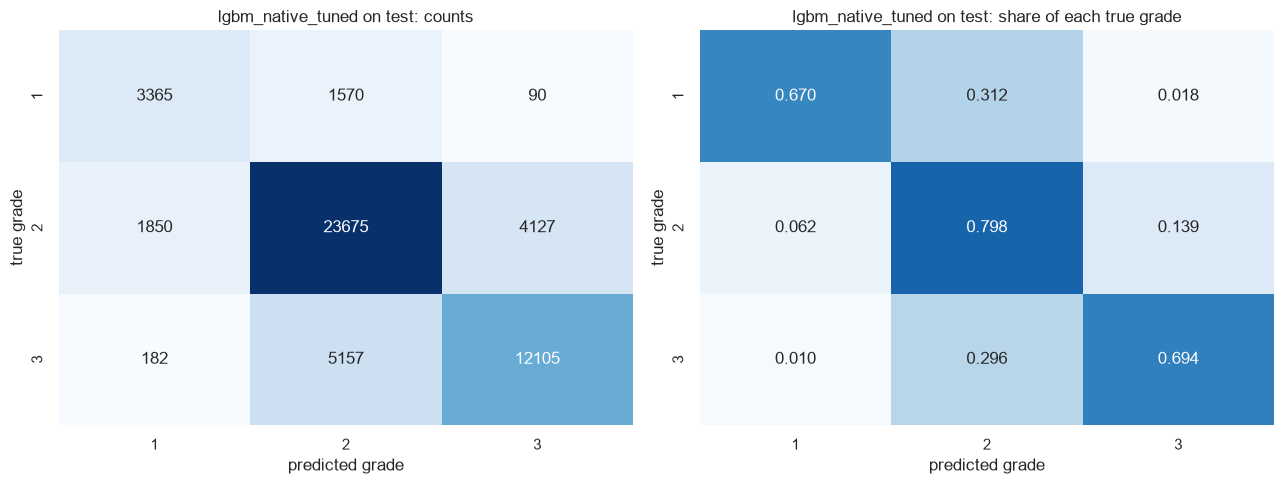

true 3 predicted as 1 (missed destruction): 182
true 1 predicted as 3 (false alarm):        90
share of grade-3 buildings predicted below 3: 0.3061


In [44]:
# counts and row shares together: shares show the pattern, counts show how many real buildings that means
cm_counts = confusion_matrix(y_test, p_prod, labels=[1, 2, 3])
cm_share = confusion_matrix(y_test, p_prod, labels=[1, 2, 3], normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False, xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
sns.heatmap(cm_share, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=axes[1], cbar=False,
            xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
for ax, t in zip(axes, ["counts", "share of each true grade"]):
    ax.set_xlabel("predicted grade"); ax.set_ylabel("true grade"); ax.set_title(f"{PROD_NAME} on test: {t}")
plt.tight_layout()
plt.show()

# the two costly directions separately: missing a destroyed building is worse for inspection than a false alarm
print("true 3 predicted as 1 (missed destruction):", int(cm_counts[2, 0]))
print("true 1 predicted as 3 (false alarm):       ", int(cm_counts[0, 2]))
print(f"share of grade-3 buildings predicted below 3: {(cm_counts[2, 0] + cm_counts[2, 1]) / cm_counts[2].sum():.4f}")

**Observations**

- Grade 3: 69.4% recognised. The main weakness is that **29.6% of destroyed buildings (5,157) are predicted as grade 2**.
- Grade 1: 67.0% recognised, 31.2% predicted as grade 2.
- Grade 2: 79.8% recognised, 13.9% predicted as grade 3 and 6.2% as grade 1.
- Severe errors are rare in both directions: **182** destroyed buildings predicted as grade 1 (1.0% of grade 3) and **90** low-damage buildings predicted as grade 3 (1.8% of grade 1). The model almost never jumps two grades, which is the ordinal behaviour wanted.
- Missing almost a third of destroyed buildings with a hard label is a practical problem. Section 12 checks whether ranking buildings by predicted probability does better.

Saving the results, decision weights and test predictions before the interpretation steps.

In [48]:
joblib.dump({"results": results, "tuning": tuning, "final_weights": final_weights, "test_out": test_out},
            "checkpoint_after_test.joblib")

['checkpoint_after_test.joblib']

## 11. Interpretation

Everything in this section describes **what the model learned from this dataset**. A feature being important for prediction does not prove that it causes damage.

### 11.1 Grouped permutation importance

Shuffling one feature at a time would understate the construction features, because foundation, roof and floor types move together (Cramér's V 0.36-0.58 in 4.8). So related columns are shuffled **together as a group** with the same row order, five times each, and I measure how much worse the test predictions get.

done in 3.3 min
                                     logloss_increase         macro_f1_drop        
                                                 mean     std          mean     std
group                                                                              
geography (geo levels 1-3)                     0.6027  0.0046        0.2920  0.0025
foundation / roof / floor types                0.0816  0.0011        0.0662  0.0018
superstructure materials                       0.0381  0.0004        0.0397  0.0013
age                                            0.0285  0.0006        0.0273  0.0003
size (floors, height, area)                    0.0152  0.0004        0.0101  0.0003
site & layout (land, position, plan)           0.0042  0.0004        0.0025  0.0004
secondary use                                  0.0039  0.0002        0.0023  0.0007
ownership & families                           0.0031  0.0001        0.0026  0.0004


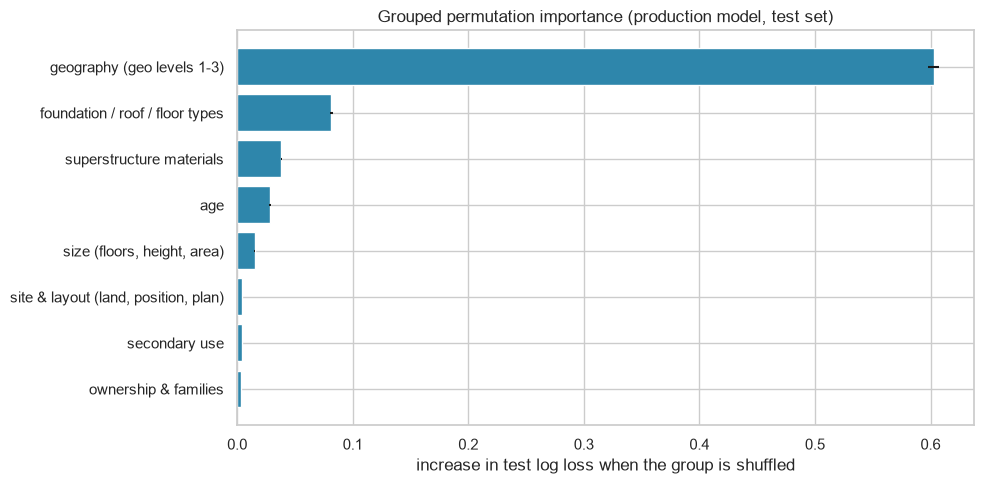

In [49]:
# shuffling one feature at a time would understate the construction features, because foundation, roof and
# floor types move together (Cramér's V 0.36-0.58 earlier). so related columns are shuffled together as a group,
# with the same row order, and I measure how much worse the predictions on the test set get
prod = fitted[PROD_NAME]
w1, w3 = final_weights[PROD_NAME]
base_P = test_out[PROD_NAME]["proba"]
base_ll = log_loss(y_test, base_P, labels=[1, 2, 3])
base_f1 = fast_macro_f1(y_test, apply_rule(base_P, w1, w3))

feature_groups = {
    "geography (geo levels 1-3)": geo_cols,
    "foundation / roof / floor types": ["foundation_type", "roof_type", "ground_floor_type", "other_floor_type"],
    "superstructure materials": super_cols,
    "size (floors, height, area)": ["count_floors_pre_eq", "height_percentage", "area_percentage"],
    "age": ["age"],
    "secondary use": ["has_secondary_use"] + sec_cols,
    "site & layout (land, position, plan)": ["land_surface_condition", "position", "plan_configuration"],
    "ownership & families": ["legal_ownership_status", "count_families"],
}

rng = np.random.default_rng(RANDOM_STATE)
rows = []
t0 = time.time()
for gname, cols in feature_groups.items():
    for rep in range(5):
        Xp = X_test.copy()
        perm = rng.permutation(len(Xp))
        for c in cols:                                   # column by column keeps each dtype intact
            Xp[c] = X_test[c].to_numpy()[perm]
        P = prod.predict_proba(Xp)
        rows.append({"group": gname,
                     "logloss_increase": log_loss(y_test, P, labels=[1, 2, 3]) - base_ll,
                     "macro_f1_drop": base_f1 - fast_macro_f1(y_test, apply_rule(P, w1, w3))})
print(f"done in {(time.time() - t0) / 60:.1f} min")

perm_imp = pd.DataFrame(rows).groupby("group").agg(["mean", "std"]).sort_values(("logloss_increase", "mean"), ascending=False)
print(perm_imp.round(4).to_string())

plt.figure(figsize=(10, 5))
plt.barh(perm_imp.index, perm_imp[("logloss_increase", "mean")], xerr=perm_imp[("logloss_increase", "std")], color="#2e86ab")
plt.gca().invert_yaxis()
plt.xlabel("increase in test log loss when the group is shuffled")
plt.title("Grouped permutation importance (production model, test set)")
plt.tight_layout()
plt.show()

**Observations** (3.3 minutes)

| feature group | log loss increase | macro F1 drop |
|---|---|---|
| geography (geo levels 1-3) | **0.603** | **0.292** |
| foundation / roof / floor types | 0.082 | 0.066 |
| superstructure materials | 0.038 | 0.040 |
| age | 0.029 | 0.027 |
| size (floors, height, area) | 0.015 | 0.010 |
| site and layout | 0.004 | 0.003 |
| secondary use | 0.004 | 0.002 |
| ownership and families | 0.003 | 0.003 |

- **Geography dominates by a wide margin**, about 7 times the next group.
- Among building characteristics, the foundation/roof/floor group matters most, followed by materials and age.
- Site layout, secondary use and ownership hardly matter to the model, which matches their weak associations in the EDA.
- The standard deviations over the five repetitions are tiny compared with the gaps between groups, so the ranking is stable.

### 11.2 Direction of the effects (SHAP values)

LightGBM can split each prediction into per-feature contributions (TreeSHAP) without extra libraries. I look at contributions to the **grade-3 score** on a sample of 5,000 test buildings: positive values push a building towards "almost destroyed", negative values away from it.

contribution array: (5000, 120) | expected: (5000, 120)


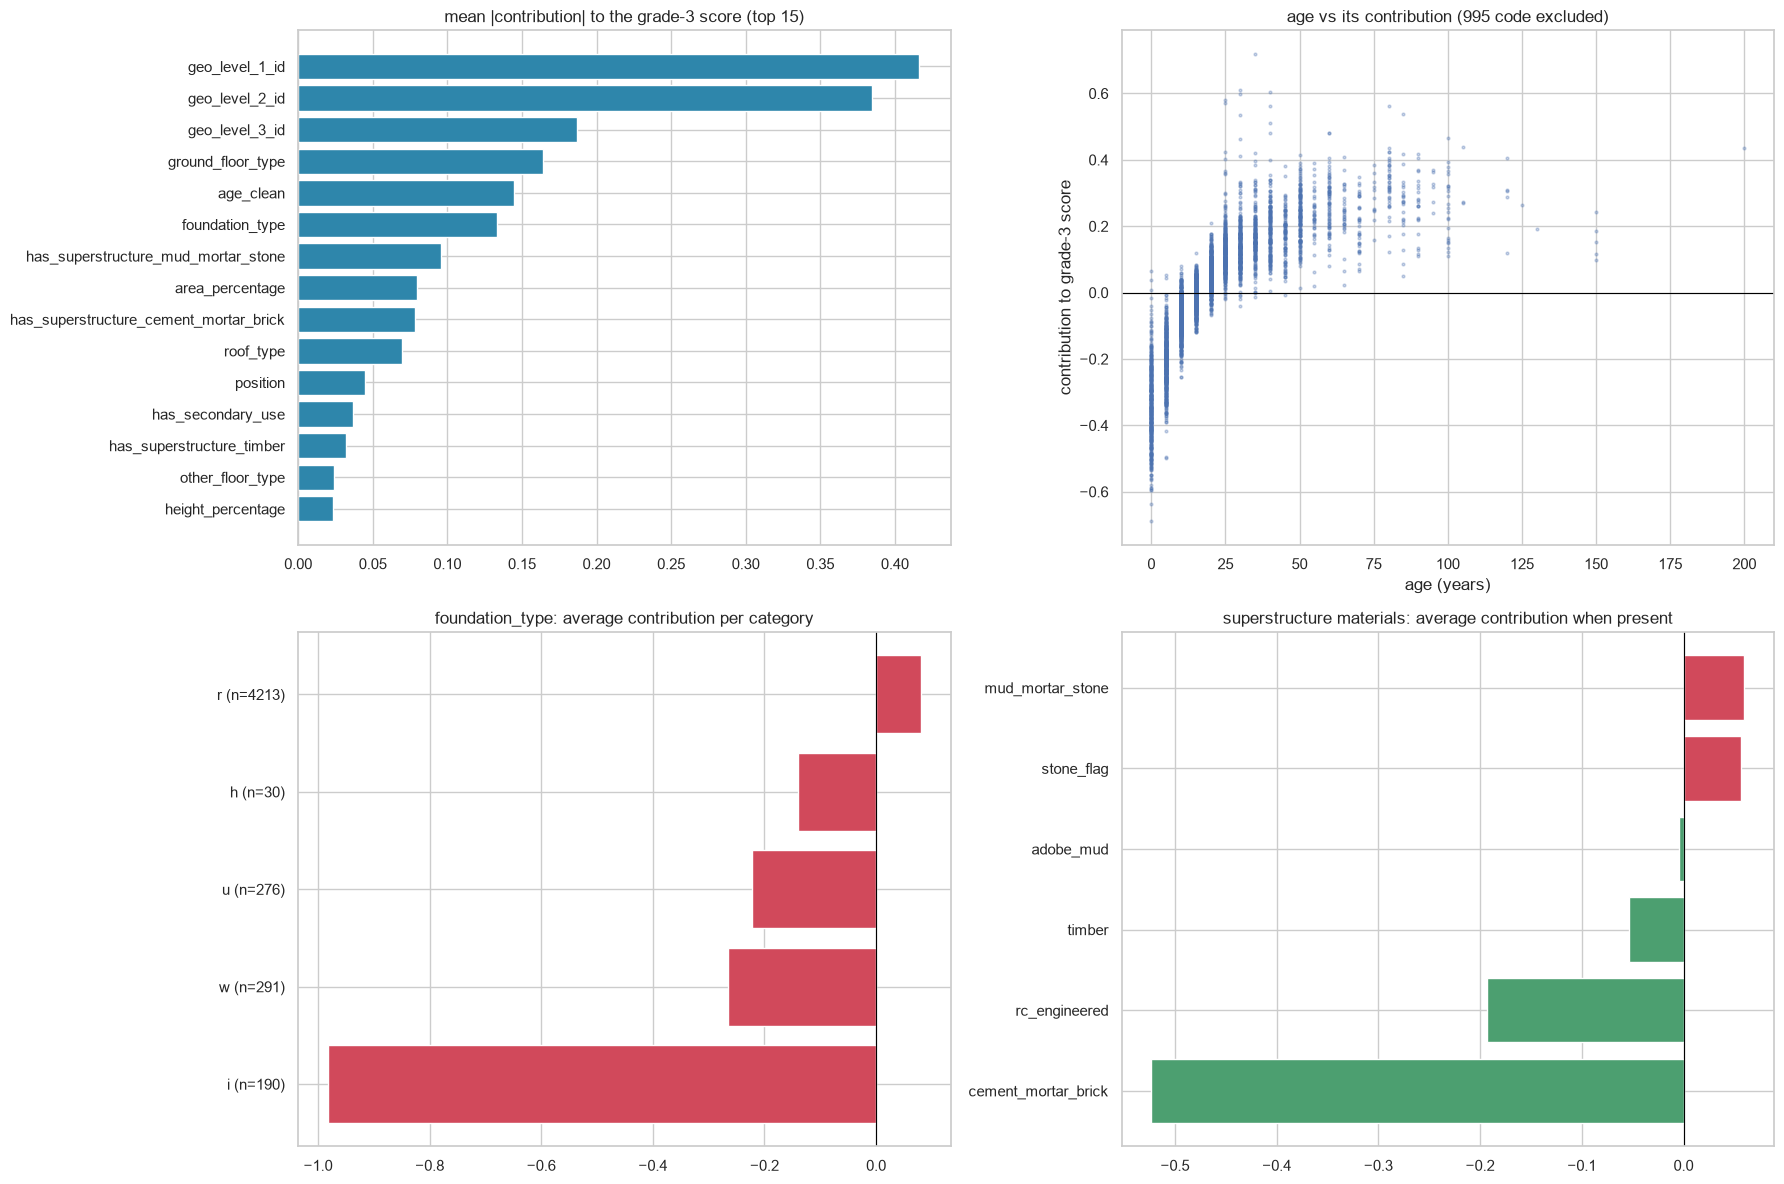


foundation_type average contribution:
                   mean  size
foundation_type             
i               -0.983   190
w               -0.265   291
u               -0.222   276
h               -0.140    30
r                0.080  4213

materials (average contribution when present):
 cement_mortar_brick   -0.523
rc_engineered         -0.193
timber                -0.054
adobe_mud             -0.004
stone_flag             0.056
mud_mortar_stone       0.060


In [46]:
# LightGBM can split each prediction into per-feature contributions (TreeSHAP) without extra libraries.
# I'm looking at the contributions to the grade-3 score: positive = pushes the building towards "destroyed".
# these show what the model learned from this data, which is association, not proof of cause
pre = prod.named_steps["pre"]
lgb_model = prod.named_steps["clf"].est_
feat_names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
F = len(feat_names)

sample = X_test.sample(5000, random_state=RANDOM_STATE)
Xt = pre.transform(sample)
contrib = lgb_model.predict(Xt, pred_contrib=True)
print("contribution array:", contrib.shape, "| expected:", (len(sample), 3 * (F + 1)))
shap3 = pd.DataFrame(contrib[:, 2 * (F + 1): 3 * (F + 1) - 1], columns=feat_names)   # grade-3 block, bias dropped
Xt_df = pd.DataFrame(Xt, columns=feat_names)

top = shap3.abs().mean().sort_values(ascending=False).head(15)
cat_enc = pre.named_transformers_["cat"]
found_labels = dict(enumerate(cat_enc.categories_[cat_cols.index("foundation_type")]))
flag_show = ["has_superstructure_mud_mortar_stone", "has_superstructure_stone_flag", "has_superstructure_adobe_mud",
             "has_superstructure_timber", "has_superstructure_cement_mortar_brick", "has_superstructure_rc_engineered"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0, 0].barh(top.index[::-1], top.values[::-1], color="#2e86ab")
axes[0, 0].set_title("mean |contribution| to the grade-3 score (top 15)")

real_age = sample["age"] != 995
axes[0, 1].scatter(Xt_df.loc[real_age.values, "age_clean"], shap3.loc[real_age.values, "age_clean"], s=4, alpha=0.3)
axes[0, 1].axhline(0, color="black", lw=0.8)
axes[0, 1].set_xlabel("age (years)"); axes[0, 1].set_ylabel("contribution to grade-3 score")
axes[0, 1].set_title("age vs its contribution (995 code excluded)")

f_codes = Xt_df["foundation_type"].astype(int).map(found_labels)
f_mean = shap3["foundation_type"].groupby(f_codes).agg(["mean", "size"]).sort_values("mean")
axes[1, 0].barh([f"{i} (n={n})" for i, n in zip(f_mean.index, f_mean["size"])], f_mean["mean"], color="#d1495b")
axes[1, 0].axvline(0, color="black", lw=0.8)
axes[1, 0].set_title("foundation_type: average contribution per category")

flag_eff = pd.Series({f.replace("has_superstructure_", ""): shap3.loc[Xt_df[f] == 1, f].mean() for f in flag_show}).sort_values()
axes[1, 1].barh(flag_eff.index, flag_eff.values, color=["#4c9f70" if v < 0 else "#d1495b" for v in flag_eff.values])
axes[1, 1].axvline(0, color="black", lw=0.8)
axes[1, 1].set_title("superstructure materials: average contribution when present")
plt.tight_layout()
plt.show()

print("\nfoundation_type average contribution:\n", f_mean.round(3).to_string())
print("\nmaterials (average contribution when present):\n", flag_eff.round(3).to_string())

**Observations**

- The largest contributions come from the three geo levels, then ground floor type, age, foundation type and mud-mortar stone.
- **Age:** the contribution rises steeply from about −0.6 at age 0 to about +0.2 at 25-30 years and then stays roughly flat. Newer buildings are strongly associated with lower predicted destruction, but beyond about 30 years extra age adds little. This matches the plateau seen in 4.3.
- **Foundation type:** `i` −0.98, `w` −0.27, `u` −0.22, `h` −0.14, while `r` (84% of the sample) is +0.08. So `r` is the typical high-risk foundation and moving away from it goes with lower predicted destruction.
- **Materials (average contribution when present):** cement-mortar brick −0.52, engineered RC −0.19, timber −0.05, adobe about 0, stone +0.06, mud-mortar stone +0.06.

**Why engineered RC and mud-mortar stone look weaker here than in the EDA.** In 4.5, engineered RC had a raw difference of −0.875 and mud-mortar stone +0.418. These features overlap with the foundation and floor types, and SHAP splits the credit between correlated features, so part of their effect is assigned to those columns. That is why the grouped permutation in 11.1 is used for "how much" and SHAP mainly for "which direction". Timber coming out close to zero agrees with the within-region check in 4.9.

## 12. Practical use: ranking buildings for inspection

A hard grade-3 label misses about 30% of destroyed buildings. An alternative is to rank every building by its predicted probability of grade 3 and work down the list. This cell measures what share of destroyed buildings an inspection team would reach for a given inspection budget.

 inspect_top_share  buildings  grade3_captured  grade3_share_in_list
               0.1       5212            0.283                 0.947
               0.2      10424            0.511                 0.855
               0.3      15636            0.676                 0.754
               0.4      20848            0.793                 0.663
               0.5      26060            0.871                 0.583

for comparison, the hard grade-3 label flags 0.313 of buildings and captures 0.694 of destroyed ones; base rate of grade 3 = 0.335


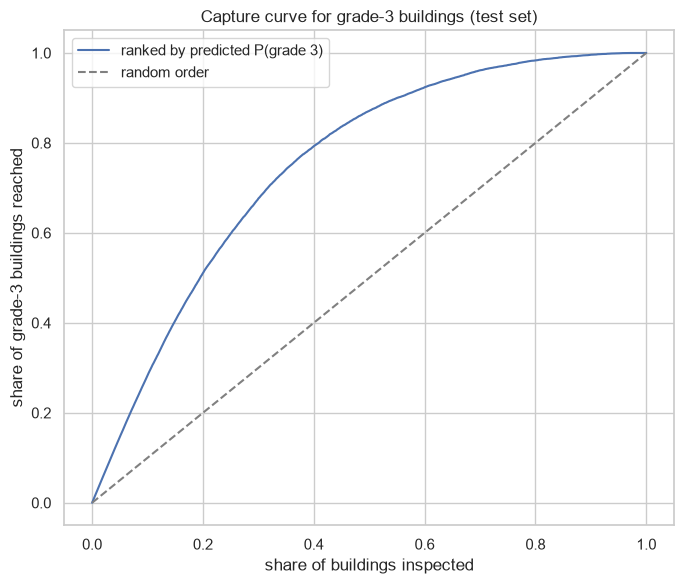

In [47]:
# a hard grade-3 label misses ~30% of destroyed buildings, so instead: rank every test building by its predicted
# probability of grade 3 and check how many destroyed buildings an inspection team would reach working down the list
P3 = test_out[PROD_NAME]["proba"][:, 2]
order = np.argsort(-P3)
is3_sorted = (y_test[order] == 3)
capture = np.cumsum(is3_sorted) / is3_sorted.sum()
share_inspected = np.arange(1, len(order) + 1) / len(order)

rows = []
for q in [0.10, 0.20, 0.30, 0.40, 0.50]:
    k = int(q * len(order))
    rows.append({"inspect_top_share": q, "buildings": k,
                 "grade3_captured": capture[k - 1], "grade3_share_in_list": is3_sorted[:k].mean()})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(f"\nfor comparison, the hard grade-3 label flags {np.mean(test_out[PROD_NAME]['pred'] == 3):.3f} of buildings "
      f"and captures {np.mean(test_out[PROD_NAME]['pred'][y_test == 3] == 3):.3f} of destroyed ones; "
      f"base rate of grade 3 = {np.mean(y_test == 3):.3f}")

plt.figure(figsize=(7, 6))
plt.plot(share_inspected, capture, label="ranked by predicted P(grade 3)")
plt.plot([0, 1], [0, 1], "--", color="grey", label="random order")
plt.xlabel("share of buildings inspected"); plt.ylabel("share of grade-3 buildings reached")
plt.title("Capture curve for grade-3 buildings (test set)")
plt.legend(); plt.tight_layout(); plt.show()

**Observations**

| share of buildings inspected | share of grade-3 buildings reached | share of the list that is grade 3 |
|---|---|---|
| top 10% | 28.3% | 94.7% |
| top 20% | 51.1% | 85.5% |
| top 30% | 67.6% | 75.4% |
| top 40% | 79.3% | 66.3% |
| top 50% | 87.1% | 58.3% |

- Inspecting the top 10% of the ranking reaches 28.3% of destroyed buildings, against about 10% for a random order, so roughly **2.8× more efficient**, and almost 95% of buildings on that short list really are grade 3.
- At the same budget as the hard label (which flags 31.3% of buildings and catches 69.4% of destroyed ones), the ranking performs about the same (67.6% at 30%).
- The real advantage is flexibility: an authority can set its inspection capacity (10%, 20%, 50%) and know in advance roughly what share of destroyed buildings it will reach.

## 13. Model comparison report

### 13.1 What was compared

All models were trained and scored on the same 5 stratified folds of the training set (208,480 buildings), with preprocessing fitted inside each fold. Every model with probabilities got the same decision rule (weights on P(grade 1) and P(grade 3), chosen on the other four folds).

**Cross-validated results with the tuned decision rule** (mean of 5 folds):

| model | accuracy | macro F1 (std) | QWK | severe err | log loss | fit / predict per fold |
|---|---|---|---|---|---|---|
| majority class (baseline, no rule) | 0.5689 | 0.2417 | 0.000 | 0.00% | - | - |
| logistic regression, location only (baseline, no rule) | 0.6426 | 0.4246 | 0.330 | 0.59% | - | 0.8 s / <0.1 s |
| logistic regression | 0.7208 | 0.6796 (0.0012) | 0.606 | 0.50% | 0.6153 | 6.0 s / 0.1 s |
| regression + learned cut points (LightGBM) | 0.7360 | 0.6986 (0.0013) | 0.629 | **0.33%** | - | 10.2 s / 0.3 s |
| random forest | 0.7397 | 0.7031 (0.0011) | 0.629 | 0.51% | 0.5755 | 14.7 s / 0.5 s |
| LightGBM, per-grade TE, default | 0.7402 | 0.7053 (0.0012) | 0.629 | 0.60% | 0.5691 | **7.5 s / 0.8 s** |
| LightGBM, per-grade TE, tuned (fast) | 0.7399 | 0.7054 (0.0005) | 0.630 | 0.61% | 0.5687 | 13.0 s / 1.1 s |
| XGBoost, per-grade TE, tuned | 0.7418 | 0.7064 (0.0013) | 0.631 | 0.58% | 0.5669 | 44.6 s / 1.2 s |
| LightGBM, per-grade TE, tuned | 0.7436 | 0.7070 (0.0010) | 0.630 | 0.56% | 0.5676 | 41.9 s / 4.4 s |
| LightGBM, native categories, default | 0.7420 | 0.7081 (0.0014) | 0.633 | 0.64% | 0.5730 | 36.3 s / 7.4 s |
| **LightGBM, native categories, tuned** | **0.7433** | **0.7082 (0.0014)** | **0.633** | 0.58% | **0.5668** | 31.4 s / 3.4 s |

Also tested and not carried forward: balanced class weights for logistic regression (fewer correct predictions overall and almost 5× more severe errors), the mean-grade target encoding (replaced by the per-grade version), the cumulative Frank and Hall approach (no gain over plain multiclass) and CatBoost (failed with scikit-learn's `clone`, replaced by LightGBM's native categories).

### 13.2 Main findings

- **Model type matters more than the specific model.** Tree models beat logistic regression by about 0.025 macro F1, but the six best tree configurations are within 0.003 of each other.
- **The decision rule mattered more than tuning.** The tuned rule added +0.0065 to +0.0163 macro F1 across the tree models (+0.0068 to +0.0099 for the four tuned ones). Hyperparameter tuning, measured with the plain decision, changed macro F1 by −0.0002 to +0.0030 for the same four models, so for every model where both were measured the rule gave the larger gain.
- **How the geography is represented made the biggest difference among the tree models.** Native categorical handling was the only change that clearly moved the top of the table.
- **Feature selection and dimensionality reduction were considered but not applied.** The feature space never became large: 39-45 columns for the tree models and 88 for logistic regression, against 166,784 training rows per fold. The one place where it could have exploded, one-hot encoding 11,595 level-3 areas, was avoided at the source by target encoding or native categories. Tree models already ignore features that don't help them split, and PCA would mix binary and categorical columns into components that can't be read as building characteristics, which Task 3 needs. The least important groups in 11.1 (site layout, secondary use, ownership) each cost only 0.003-0.004 log loss when shuffled, so dropping them could simplify the model slightly; I did not run that removal experiment.
- **The ordinal structure** is used through the metrics (QWK, MAE, severe errors), the decision rule and two ordinal models. The regression with cut points gives the fewest severe errors; the cumulative approach gave nothing extra.

### 13.3 Production recommendation

**LightGBM with native categorical handling, tuned, plus the tuned decision rule** (`production_model.joblib`, saved with its weights w1 = 1.50, w3 = 1.20).

Test-set performance (52,121 buildings, used once): **macro F1 0.7171** (95% interval 0.7125-0.7215), accuracy 0.7510, QWK 0.6462, severe errors 0.52%, log loss 0.5512. Its advantage over the lightweight alternative on the test set is +0.0050 macro F1 (interval +0.0020 to +0.0080).

Trade-offs considered:

- **Performance:** in cross-validation it has the highest macro F1 (0.7082), the highest QWK (0.6333) and the lowest log loss (0.5668) of all models compared. The margins at the top are very small (macro F1 only 0.0001 above the untuned native model, log loss 0.0001 below tuned XGBoost). It is **not** best on every metric: the tuned target-encoded LightGBM has slightly higher CV accuracy (0.7436 vs 0.7433) and lower MAE (0.2620 vs 0.2625), and the random forest (0.51%) and the regression with learned cut points (0.33%) make fewer severe errors (production: 0.58%). On the test set it beat the lightweight alternative on every reported metric.
- **Cost:** about 4× the training and prediction time of the lightweight model, but small in absolute terms (38 s to train on all 208,480 buildings, 4.7 s to score 52,121).
- **Stability:** fold standard deviation 0.0014, similar to the others. It is sensitive to its settings, so retraining should keep the tuned settings.
- **Interpretability and maintenance:** harder to explain how it uses thousands of area ids than the single "area mean grade" of the target-encoded model.
- **Alternatives:** the default per-grade target-encoded LightGBM if simplicity and speed matter more than 0.005 macro F1; the regression with learned cut points if 1↔3 mistakes are the main concern.

### 13.4 How the predictions could be used

These are possible uses that follow from the results; nothing here has been deployed.

- **Inspection priority after an event.** Ranking buildings by predicted P(grade 3) reaches 51% of destroyed buildings in the top 20% of the list (Section 12). Teams can choose the cut-off that matches their capacity.
- **Resource allocation.** Because geography dominates the predictions, the predicted damage distribution per area can show where heavy damage is concentrated and where to send teams or supplies first.
- **Pre-event vulnerability screening.** The building characteristics associated with lower predicted damage (certain foundation/floor/roof types, cement-mortar brick, engineered RC, newer buildings) can help shortlist buildings for retrofitting checks, as long as the codes can be mapped back to real construction types.
- **Probability over hard labels.** The probabilities are reasonably good (test log loss 0.551), so it is better to use them for ranking than to rely only on the hard grade, which misses about 30% of destroyed buildings.

## 14. Suggestions to seismologists (Task 3)

The brief asks how to avoid an earthquake leading to significant damage in many buildings. Earthquakes themselves can't be prevented, so these suggestions are about **reducing damage when one happens**. Each point is tied to a result in this notebook, and each describes an **association within this dataset**, not a proven cause.

**1. Treat location as the first layer of risk.**
*Evidence:* geography is by far the strongest predictor (shuffling it raises test log loss by 0.603, against 0.082 for the next group). Regions 17, 18, 21 and 8 had over 50% of buildings almost destroyed, against under 10% in regions 26, 24 and 5 (4.6).
*Suggestion:* combine ground-shaking maps, fault distance and soil or microzonation studies with damage predictions like these. That is the only way to separate "the ground shook harder here" from "buildings here are built differently", which this dataset cannot do on its own.

**2. Prioritise retrofitting and inspection by foundation and wall type.**
*Evidence:* foundation type `r` and mud-mortar stone or stone walls are associated with the most damage, and this held **within the same region** (mud-mortar stone +0.418 raw, +0.481 within regions). Foundation type `i`, engineered RC and cement-mortar brick are associated with the least damage (4.5, 4.9, 11.2).
*Suggestion:* use these associations to rank building types for retrofitting programmes. Because the categories are obfuscated, the codes first need to be mapped back to real foundation, roof and floor types using the original survey.

**3. Inspect older buildings first, but don't rely on age alone.**
*Evidence:* the share of low damage drops from 27.8% for brand-new buildings to about 4% for 25-50 years; the model's contribution of age rises until about 25-30 years and then levels off (4.3, 11.2).
*Suggestion:* age is a useful screening factor up to about 30 years; beyond that, construction type tells more than extra age.

**4. Don't read every "protective" pattern at face value.**
*Evidence:* timber and bamboo looked protective in the raw data, but the effect disappeared within regions (4.9). Rental and hotel use also go with lower damage, most likely because of which buildings are used that way.
*Suggestion:* check apparent effects within comparable areas before turning them into building advice.

**5. Use predicted probabilities for triage, not only hard labels.**
*Evidence:* the top 10% of the risk ranking contains 28% of destroyed buildings, and 95% of that short list really is grade 3 (Section 12).

**6. Collect the data that would make the analysis causal-ready.**
*Evidence:* this dataset has no shaking intensity, distance to the epicentre or soil type, and age is sometimes missing (the 995 code).
*Suggestion:* recording shaking intensity per area, soil class, distance to the rupture, reliable construction year and engineering details in future surveys would allow location effects and construction effects to be separated properly.

## 15. Report on challenges faced

Each challenge below actually came up while building this notebook.

**1. Imbalanced, ordinal target**
- *What happened:* grade 1 is only 9.6% of buildings. The location-only baseline never predicted grade 1 (recall 0), and even the best untuned models only reached grade-1 recall of about 0.52.
- *How it was detected:* per-grade recall in `ordinal_metrics` and the confusion matrices (5.2, 5.6).
- *What I did:* first tried balanced class weights, which over-corrected (severe errors 0.27% → 1.27%). Then I tuned a decision rule on the predicted probabilities, with weights chosen on the other four folds only (7.1).
- *Why:* it changes how probabilities become grades without retraining, works the same way for every model (fair comparison), and the target's order is respected through QWK, MAE and the severe-error count.
- *Effect:* +0.0065 to +0.0163 macro F1 across the tree models, and grade-1 recall from 0.49-0.56 to 0.66-0.68, at the cost of 0.5-0.7 points of accuracy and a higher severe-error rate.

**2. The `age = 995` code**
- *What happened:* `age` jumps from 200 straight to 995 for 1,110 training buildings.
- *How it was detected:* only 42 distinct age values in the summary table, then listing them (4.1).
- *What I did:* compared these buildings with real age groups (mean grade 2.159, close to the 5-20 year group) and treated 995 as "unknown": a separate flag plus the training-fold median in `AgeCleaner`.
- *Why:* left as is, 995 would act as an extreme age and distort linear and distance-based models.
- *Effect:* not measured separately; the 995 buildings are 0.5% of the data.

**3. High-cardinality geography and target leakage**
- *What happened:* 11,595 level-3 areas with a median of 12 buildings each. Raw area means overfit: in-sample R² 0.429 vs out-of-fold 0.360 (4.7).
- *What I did:* cross-fitted `TargetEncoder` inside the pipelines, then compared it with per-grade encoding and with LightGBM's native categories.
- *Why:* cross-fitting keeps a building's own label out of its encoding; the native approach lets the model group areas itself.
- *Effect:* encoded level 3 reaches Spearman 0.586 with damage on unseen validation rows; native categories gave the best final model (+0.003 macro F1 over per-grade encoding in CV, +0.005 on the test set).

**4. Duplicate buildings with conflicting labels**
- *What happened:* 3,825 feature profiles occur with different damage grades (2.1).
- *What I did:* kept them, because they are separate buildings.
- *Effect:* this limits how well any model can do. It is consistent with the very flat tuning results for the target-encoded LightGBM (all top five settings within 0.002 log loss of the default).

**5. Location mixed up with construction**
- *What happened:* some raw associations could be location effects in disguise.
- *What I did:* compared buildings within the same top-level region (4.9).
- *Effect:* timber and bamboo lost their apparent protective effect completely, which prevented a wrong suggestion in Section 14.

**6. Very slow logistic regression**
- *What happened:* the logistic regression cross-validation ran for over 30 minutes without finishing.
- *How it was detected:* timing preprocessing and fitting separately on one fold, and checking the matrix rank (5.5).
- *What I did:* `drop="first"` in the one-hot encoder. The full-dummy encoding had rank 89 for 97 columns.
- *Why:* it removes the exact collinearity at its source without losing information, and keeps the same model, so the comparison stays fair. Subsampling or a looser tolerance would have weakened the linear model for reasons unrelated to the model itself.
- *Effect:* one fit went from 64.6 s to 4.7 s.

**7. Library compatibility issues**
- *CatBoost:* failed scikit-learn's `clone()` check because its constructor converts `cat_features` internally (5.9). I replaced the experiment with LightGBM's native categories, which answered the same question with the same library.
- *XGBoost:* expects labels 0/1/2; handled by the `LabelSafe` wrapper. It also returns float32 probabilities that trigger a sum-to-one warning in `log_loss`; the effect is around 1e-7, and the final comparison renormalises the probabilities.
- *scikit-learn 1.9:* `TargetEncoder(random_state=...)` is deprecated, so the shuffled inner folds are passed explicitly as `cv=KFold(...)`.

**8. Cost of the native-category search and a frozen kernel**
- *What happened:* native-category fits took about 15 s to 3 minutes each. During the first search run the laptop went to sleep: one fit's timer showed over 19 hours, and the kernel then froze completely (CPU near 0%, interrupt had no effect). `RandomizedSearchCV` keeps results only at the end, so the finished fits were lost, and the restart also cleared all stored model results. (The log of that interrupted run is not kept in this notebook.)
- *How it was detected:* fit times far out of line with similar settings, then CPU usage near zero while the cell was still marked as running.
- *What I did:* saved results to disk with `joblib` after every expensive step, kept the machine awake during long runs, and re-ran the search.
- *Effect:* the clean re-run finished in 81.8 minutes, and later steps can be reloaded instead of recomputed.

**9. Choosing between metrics that disagree**
- *What happened:* balanced logistic regression raised QWK while lowering macro F1 and increasing severe errors (5.4).
- *What I did:* used macro F1 as the main selection metric, with QWK and severe errors as ordinal checks and accuracy for comparability with the competition.
- *Why:* QWK alone rewards pushing predictions to the outer grades, which here also meant more costly mistakes.

## 16. Limitations

- **Observational data from one earthquake.** All findings are associations within the Gorkha data. They may not transfer to another earthquake with a different epicentre, depth or building stock, and the geo ids are specific to this region.
- **No shaking or soil information.** The dominant geography effect cannot be split into ground shaking and regional building practice.
- **Obfuscated categories.** Codes like `r` or `i` can't be translated into real construction types without the original survey key.
- **Random split.** Train and test buildings share the same areas (only 0.49% of test buildings are in level-3 areas unseen in training). Performance on a completely new region would very likely be lower.
- **Slightly optimistic CV for tuned models**, because their settings were chosen on 3 of the same 5 folds. The untouched test set is the reference for final performance.
- **Unavoidable error.** 3,825 identical feature profiles carry different grades, so part of the remaining error can't be removed with these features.

## 17. Conclusion

The goal was to predict the ordinal damage grade of buildings hit by the 2015 Gorkha earthquake, compare several models fairly, and turn the results into suggestions for reducing damage.

- **Data analysis:** the data is clean (no missing values) but has a hidden age code (995), strong class imbalance (9.6% grade 1), 3,825 conflicting duplicate profiles and very high-cardinality geography. Location is by far the strongest factor: damage ranges from 8.8% grade 3 in one region to 80.6% in another. Among building characteristics, foundation type and wall material show the clearest associations, and most of them hold within the same region, while timber and bamboo do not.
- **Modelling:** tree models clearly beat logistic regression. Tuning the decision rule on predicted probabilities helped more than hyperparameter tuning (+0.0065 to +0.0163 macro F1 versus at most +0.0030). The best model is **LightGBM with native categorical handling, tuned, with a tuned decision rule**: macro F1 0.7082 in cross-validation and **0.7171 on the test set** (accuracy 0.7510, QWK 0.6462, severe errors 0.52%). Its edge over a simpler and 4× cheaper LightGBM is small but confirmed on the test set (+0.0050 macro F1, interval +0.0020 to +0.0080).
- **Use:** ranking buildings by predicted probability of grade 3 reaches 51% of destroyed buildings in the top 20% of the list, which is more useful for inspection planning than the hard labels alone.
- **Suggestions:** treat location as the first layer of risk and combine predictions with shaking and soil data; focus retrofitting on the foundation and wall types associated with high damage; use age as a screening factor up to about 30 years; and collect shaking, soil and reliable age data in future surveys.

All of these findings are associations in observational data from one earthquake. The model shows where damage was concentrated and which building characteristics went with it, which is useful for planning, but it doesn't prove that changing a characteristic would prevent damage.